#  PyTorch - Neural Networks
### A Complete Interactive Guide for Beginners

---

Welcome! This notebook is your **end-to-end guide** to PyTorch. We start from the very mathematical foundations — tensors, linear algebra, differentiation — and build all the way up to training a **Convolutional Neural Network on CIFAR-10**.

**What you'll learn:**
- Tensors and the linear algebra behind them
- Automatic differentiation and how PyTorch builds computation graphs
- Backpropagation: by hand, then with autograd
- The PyTorch toolbox: `nn`, `optim`, `DataLoader`, and more
- Convolutions: the math, the shapes, the intuition
- Building and training a CNN on CIFAR-10

---
> 💡 **How to use this notebook**: Run each cell in order. Markdown cells explain concepts. Code cells let you experiment — modify them freely!
---

In [1]:
# ─── Install / import everything we need ───────────────────────────────────
# Run this cell first to make sure all dependencies are available.
# On Google Colab, torch is pre-installed. Locally: pip install torch torchvision matplotlib networkx

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import networkx as nx
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Set a global seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Detect GPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' PyTorch version : {torch.__version__}')
print(f' Device          : {DEVICE}')

 PyTorch version : 2.9.1+cpu
 Device          : cpu


---
# Part 1 — Tensors and Linear Algebra 
---

## 1.1 What is a Tensor?

Before we touch code, let's build the right mental model.

### Scalars, Vectors, Matrices … Tensors

A **tensor** is a generalisation of scalars, vectors, and matrices to an arbitrary number of dimensions (called **rank** or **order**).

| Object | Rank | Shape example | LaTeX |
|---|---|---|---|
| Scalar | 0 | `()` | $x \in \mathbb{R}$ |
| Vector | 1 | `(n,)` | $\mathbf{x} \in \mathbb{R}^n$ |
| Matrix | 2 | `(m, n)` | $\mathbf{X} \in \mathbb{R}^{m \times n}$ |
| 3-D Tensor | 3 | `(b, m, n)` | $\mathcal{X} \in \mathbb{R}^{b \times m \times n}$ |

---

### Tensor vs Matrix — Key Differences

| | Matrix | Tensor |
|---|---|---|
| **Dimensions** | Always 2D | Any number of dimensions |
| **Transformation** | Represents a linear map $\mathbb{R}^n \to \mathbb{R}^m$ | Represents multi-linear maps |
| **Indexing** | Two indices $A_{ij}$ | $k$ indices $T_{i_1 i_2 \ldots i_k}$ |
| **PyTorch** | `tensor.dim() == 2` | `tensor.dim() >= 0` |

In deep learning, almost every object is a tensor:
- A **grayscale image** is a rank-2 tensor: $(H, W)$
- A **colour image** is rank-3: $(C, H, W)$
- A **batch of colour images** is rank-4: $(B, C, H, W)$

---

### Essential Linear Algebra

**Matrix multiplication** (the most important operation in ML):

$$\mathbf{C} = \mathbf{A} \mathbf{B}, \quad C_{ij} = \sum_k A_{ik} B_{kj}$$

For $\mathbf{A} \in \mathbb{R}^{m \times k}$ and $\mathbf{B} \in \mathbb{R}^{k \times n}$, we get $\mathbf{C} \in \mathbb{R}^{m \times n}$.

**Dot product** of two vectors:

$$\mathbf{a} \cdot \mathbf{b} = \sum_i a_i b_i = \|\mathbf{a}\| \|\mathbf{b}\| \cos\theta$$

**Element-wise (Hadamard) product**:

$$(\mathbf{A} \odot \mathbf{B})_{ij} = A_{ij} B_{ij}$$

**Transpose**: $(\mathbf{A}^\top)_{ij} = A_{ji}$

**Norms** (measure of magnitude):
$$\|\mathbf{x}\|_2 = \sqrt{\sum_i x_i^2}, \quad \|\mathbf{x}\|_1 = \sum_i |x_i|$$

In [2]:
# ─── 1.2 Creating Tensors ──────────────────────────────────────────────────
print('=' * 55)
print('  Creating Tensors')
print('=' * 55)

# ── Scalar (rank-0) ───────────────────────────────────────────────
scalar = torch.tensor(3.14)
print(f'Scalar   : {scalar}  | shape: {scalar.shape}  | rank: {scalar.dim()}')

# ── Vector (rank-1) ───────────────────────────────────────────────
vector = torch.tensor([1.0, 2.0, 3.0, 4.0])
print(f'Vector   : {vector}  | shape: {vector.shape}  | rank: {vector.dim()}')

# ── Matrix (rank-2) ───────────────────────────────────────────────
matrix = torch.tensor([[1., 2., 3.],
                        [4., 5., 6.]])
print(f'Matrix:\n{matrix}  | shape: {matrix.shape}  | rank: {matrix.dim()}')

# ── 3D Tensor (rank-3): think of it as a batch of 2 matrices ──────
tensor_3d = torch.randn(2, 3, 4)   # 2 matrices, each 3×4
print(f'\n3D Tensor shape: {tensor_3d.shape}  | rank: {tensor_3d.dim()}')

# ── Factory functions ─────────────────────────────────────────────
print('\nFactory functions:')
print(f'  torch.zeros(2,3)  :\n{torch.zeros(2,3)}')
print(f'  torch.ones(2,3)   :\n{torch.ones(2,3)}')
print(f'  torch.eye(3)      :\n{torch.eye(3)}')
print(f'  torch.arange(0,10,2): {torch.arange(0, 10, 2)}')
print(f'  torch.linspace(0,1,5): {torch.linspace(0, 1, 5)}')

  Creating Tensors
Scalar   : 3.140000104904175  | shape: torch.Size([])  | rank: 0
Vector   : tensor([1., 2., 3., 4.])  | shape: torch.Size([4])  | rank: 1
Matrix:
tensor([[1., 2., 3.],
        [4., 5., 6.]])  | shape: torch.Size([2, 3])  | rank: 2

3D Tensor shape: torch.Size([2, 3, 4])  | rank: 3

Factory functions:
  torch.zeros(2,3)  :
tensor([[0., 0., 0.],
        [0., 0., 0.]])
  torch.ones(2,3)   :
tensor([[1., 1., 1.],
        [1., 1., 1.]])
  torch.eye(3)      :
tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])
  torch.arange(0,10,2): tensor([0, 2, 4, 6, 8])
  torch.linspace(0,1,5): tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


In [3]:
# ─── 1.3 Data Types (dtypes) ───────────────────────────────────────────────
# dtype determines memory size and precision
print('Common dtypes in PyTorch:')
examples = [
    ('torch.float32  (default)', torch.tensor(1.0)),
    ('torch.float64  (double) ', torch.tensor(1.0, dtype=torch.float64)),
    ('torch.float16  (half)   ', torch.tensor(1.0, dtype=torch.float16)),
    ('torch.int32    (int)    ', torch.tensor(1, dtype=torch.int32)),
    ('torch.int64    (long)   ', torch.tensor(1, dtype=torch.int64)),
    ('torch.bool              ', torch.tensor(True)),
]
for name, t in examples:
    print(f'  {name}  → dtype: {t.dtype}')

# Casting
x = torch.tensor([1, 2, 3], dtype=torch.int32)
x_float = x.float()   # or x.to(torch.float32)
print(f'\nCasting int → float: {x} → {x_float}')

Common dtypes in PyTorch:
  torch.float32  (default)  → dtype: torch.float32
  torch.float64  (double)   → dtype: torch.float64
  torch.float16  (half)     → dtype: torch.float16
  torch.int32    (int)      → dtype: torch.int32
  torch.int64    (long)     → dtype: torch.int64
  torch.bool                → dtype: torch.bool

Casting int → float: tensor([1, 2, 3], dtype=torch.int32) → tensor([1., 2., 3.])


In [4]:
# ─── 1.4 Linear Algebra Operations in PyTorch ─────────────────────────────
A = torch.tensor([[1., 2.],
                   [3., 4.],
                   [5., 6.]])   # shape (3, 2)

B = torch.tensor([[7., 8., 9.],
                   [10., 11., 12.]])  # shape (2, 3)

# Matrix multiplication: A (3×2) @ B (2×3) → C (3×3)
C = A @ B   # same as torch.matmul(A, B)
print(f'A @ B =\n{C}  | shape: {C.shape}')

# Transpose
print(f'\nA.T =\n{A.T}  | shape: {A.T.shape}')

# Element-wise operations
X = torch.tensor([[1., 2.], [3., 4.]])
Y = torch.tensor([[5., 6.], [7., 8.]])
print(f'\nX * Y (element-wise) =\n{X * Y}')
print(f'X + Y =\n{X + Y}')

# Dot product of two vectors
a = torch.tensor([1., 2., 3.])
b = torch.tensor([4., 5., 6.])
print(f'\nDot product a·b = {torch.dot(a, b)}')

# Norms
print(f'L2 norm of a = {torch.norm(a):.4f}')
print(f'L1 norm of a = {torch.norm(a, p=1):.4f}')

# Determinant and inverse (square matrices)
M = torch.tensor([[2., 1.], [5., 3.]])
print(f'\ndet(M) = {torch.det(M):.4f}')
print(f'M_inv =\n{torch.inverse(M)}')

A @ B =
tensor([[ 27.,  30.,  33.],
        [ 61.,  68.,  75.],
        [ 95., 106., 117.]])  | shape: torch.Size([3, 3])

A.T =
tensor([[1., 3., 5.],
        [2., 4., 6.]])  | shape: torch.Size([2, 3])

X * Y (element-wise) =
tensor([[ 5., 12.],
        [21., 32.]])
X + Y =
tensor([[ 6.,  8.],
        [10., 12.]])

Dot product a·b = 32.0
L2 norm of a = 3.7417
L1 norm of a = 6.0000

det(M) = 1.0000
M_inv =
tensor([[ 3., -1.],
        [-5.,  2.]])


In [5]:
# ─── 1.5 Indexing, Slicing, Reshaping ─────────────────────────────────────
T = torch.arange(24).reshape(2, 3, 4).float()
print(f'T shape: {T.shape}')
print(f'T[0]   : \n{T[0]}       (first slice along dim-0)')
print(f'T[0, 1]: {T[0, 1]}   (row 1 of first slice)')
print(f'T[0, 1, 2]: {T[0, 1, 2]}  (single element)')

# Reshaping
flat = T.reshape(-1)         # flatten to 1D, -1 means 'infer'
print(f'\nFlattened shape: {flat.shape}')
T2 = flat.reshape(4, 6)      # reshape to (4, 6)
print(f'Reshaped (4,6): {T2.shape}')

# view vs reshape (view requires contiguous memory)
T3 = flat.view(6, 4)         # same as reshape when memory is contiguous
print(f'Viewed  (6,4) : {T3.shape}')

# Squeezing / unsqueezing dimensions
x = torch.tensor([1., 2., 3.])          # shape (3,)
print(f'\nOriginal: {x.shape}')
print(f'Unsqueeze dim 0: {x.unsqueeze(0).shape}')  # (1, 3) — adds batch dim
print(f'Unsqueeze dim 1: {x.unsqueeze(1).shape}')  # (3, 1) — column vector

T shape: torch.Size([2, 3, 4])
T[0]   : 
tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])       (first slice along dim-0)
T[0, 1]: tensor([4., 5., 6., 7.])   (row 1 of first slice)
T[0, 1, 2]: 6.0  (single element)

Flattened shape: torch.Size([24])
Reshaped (4,6): torch.Size([4, 6])
Viewed  (6,4) : torch.Size([6, 4])

Original: torch.Size([3])
Unsqueeze dim 0: torch.Size([1, 3])
Unsqueeze dim 1: torch.Size([3, 1])


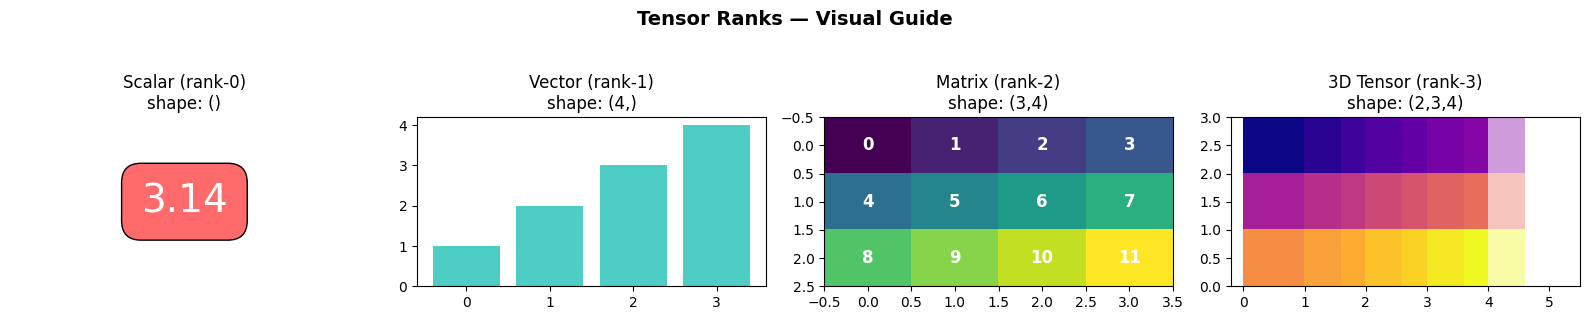

In [6]:
# ─── 1.6 Visualising Tensor Dimensions ────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

titles  = ['Scalar (rank-0)', 'Vector (rank-1)',
           'Matrix (rank-2)', '3D Tensor (rank-3)']
shapes  = ['()', '(4,)', '(3,4)', '(2,3,4)']
colours = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# Scalar
axes[0].text(0.5, 0.5, '3.14', ha='center', va='center',
             fontsize=28, color='white',
             bbox=dict(boxstyle='round,pad=0.5', facecolor=colours[0]))
axes[0].set_title(f'{titles[0]}\nshape: {shapes[0]}')
axes[0].axis('off')

# Vector
data_v = np.array([1, 2, 3, 4])
axes[1].bar(range(4), data_v, color=colours[1])
axes[1].set_title(f'{titles[1]}\nshape: {shapes[1]}')
axes[1].set_xticks(range(4))

# Matrix
data_m = np.arange(12).reshape(3, 4)
im = axes[2].imshow(data_m, cmap='viridis', aspect='auto')
for i in range(3):
    for j in range(4):
        axes[2].text(j, i, str(data_m[i,j]), ha='center', va='center',
                     color='white', fontsize=12, fontweight='bold')
axes[2].set_title(f'{titles[2]}\nshape: {shapes[2]}')

# 3D Tensor — show two 'slices'
data_3 = np.arange(24).reshape(2, 3, 4)
for idx, (offset, alpha) in enumerate([(0, 1.0), (0.3, 0.4)]):
    im3 = axes[3].imshow(data_3[idx] + offset*10,
                          cmap='plasma', aspect='auto',
                          alpha=alpha, extent=[idx*0.6, idx*0.6+4, 0, 3])
axes[3].set_title(f'{titles[3]}\nshape: {shapes[3]}')
axes[3].set_xlim(-0.2, 5.5)

plt.suptitle('Tensor Ranks — Visual Guide', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---
# Part 2 — Automatic Differentiation with `autograd` 
---

## 2.1 What is Automatic Differentiation?

When we train neural networks, we need to compute **gradients** of a loss function with respect to millions of parameters. Doing this by hand is impossible.

**Automatic Differentiation (autograd)** is a technique to compute exact derivatives of any computation expressed as code, using the **chain rule** of calculus.

### The Chain Rule — The Engine Behind It All

If $z = f(g(x))$, then:

$$\frac{dz}{dx} = \frac{dz}{dg} \cdot \frac{dg}{dx}$$

More generally, if $y = f(z)$ and $z = g(x)$:

$$\frac{dy}{dx} = \frac{dy}{dz} \cdot \frac{dz}{dx}$$

PyTorch builds a **dynamic computation graph** (a DAG — Directed Acyclic Graph) as you execute operations on tensors with `requires_grad=True`. When you call `.backward()`, it traverses this graph **backwards** to accumulate gradients.

---

## 2.2 `requires_grad` and `retain_grad`

| Attribute | What it does |
|---|---|
| `requires_grad=True` | Tells PyTorch: *track all operations on this tensor* |
| `.grad` | Stores the computed gradient after `.backward()` |
| `.retain_grad()` | For **non-leaf** tensors: keep their `.grad` after backward |
| `.detach()` | Creates a tensor with the same data but no gradient tracking |
| `torch.no_grad()` | Context manager: no gradient tracking (e.g., during inference) |

**Leaf tensors**: tensors you create directly (your inputs and parameters)  
**Non-leaf tensors**: tensors produced by operations (intermediate results)

By default, PyTorch **does not retain gradients for non-leaf tensors** to save memory. That's where `retain_grad()` comes in.

In [ ]:
# ─── 2.3 Basic Gradient: dz/dx where z = x² ───────────────────────────────
# Analytically: dz/dx = 2x. At x=3, that's 6.

x = torch.tensor(3.0, requires_grad=True)   # leaf tensor
z = x ** 2                                   # z = x²

print(f'x = {x}')
print(f'z = x² = {z}')
print(f'Is z a leaf? {z.is_leaf}')   # False — it was created by an op
print(f'z.grad_fn: {z.grad_fn}')     # PowBackward — remembers how z was made

z.backward()   # compute dz/dx

print(f'\nAfter backward():')
print(f'x.grad = {x.grad}  (expected 2*3 = 6) ')

x = 3.0
z = x² = 9.0
Is z a leaf? False
z.grad_fn: <PowBackward0 object at 0x000002C0ADD07670>

After backward():
x.grad = 6.0  (expected 2*3 = 6) ✅


In [8]:
# ─── 2.4 Gradients w.r.t. Two Variables ───────────────────────────────────
# z = x²y + y³
# ∂z/∂x = 2xy  →  at (x=2, y=3): 2*2*3 = 12
# ∂z/∂y = x² + 3y²  →  at (x=2, y=3): 4 + 27 = 31

x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

z = x**2 * y + y**3

print(f'z = x²y + y³ = {z.item():.4f}')

z.backward()

print(f'\n∂z/∂x = {x.grad.item()}  (expected 12) ✅')
print(f'∂z/∂y = {y.grad.item()}  (expected 31) ✅')

z = x²y + y³ = 39.0000

∂z/∂x = 12.0  (expected 12) ✅
∂z/∂y = 31.0  (expected 31) ✅


In [9]:
# ─── 2.5 Chain Rule: y = f(z), z = g(x) — and retain_grad ────────────────
#
# Let: z = x²   →  dz/dx = 2x
#      y = z³   →  dy/dz = 3z²
#
# By chain rule: dy/dx = dy/dz * dz/dx = 3z² * 2x = 6x * x⁴ = 6x⁵
# At x=2: dy/dx = 6*(2⁵) = 6*32 = 192
#         dy/dz = 3*(2²)² = 3*16 = 48    (z=x²=4 at x=2)

x = torch.tensor(2.0, requires_grad=True)
z = x ** 2       # non-leaf
y = z ** 3       # non-leaf

# ⚠️  Without retain_grad(), z.grad will be None after backward()
# because z is a non-leaf tensor. Let's demonstrate:

y.backward()
print('WITHOUT retain_grad():')
print(f'  x.grad (dy/dx) = {x.grad}  (expected 192) ✅')
print(f'  z.grad (dy/dz) = {z.grad}  ← None! (non-leaf, grad discarded) ⚠️')

# Now let's fix it with retain_grad()
x = torch.tensor(2.0, requires_grad=True)
z = x ** 2
z.retain_grad()   # 🔑 tell PyTorch to keep z's gradient
y = z ** 3

y.backward()
print('\nWITH retain_grad():')
print(f'  x.grad (dy/dx) = {x.grad}  (expected 192) ✅')
print(f'  z.grad (dy/dz) = {z.grad}  (expected 48)  ✅')

WITHOUT retain_grad():
  x.grad (dy/dx) = 192.0  (expected 192) ✅
  z.grad (dy/dz) = None  ← None! (non-leaf, grad discarded) ⚠️

WITH retain_grad():
  x.grad (dy/dx) = 192.0  (expected 192) ✅
  z.grad (dy/dz) = 48.0  (expected 48)  ✅


In [10]:
# ─── 2.6 Deeper Nesting: w → z → y → L ────────────────────────────────────
#
# w = input
# z = sin(w)
# y = exp(z)
# L = y²       (loss)
#
# dL/dw = dL/dy * dy/dz * dz/dw
#       = 2y   * exp(z) * cos(w)
#       = 2*exp(sin(w)) * exp(sin(w)) * cos(w)
#       = 2 * exp(2*sin(w)) * cos(w)
#
# At w = π/4:
# sin(π/4) = √2/2 ≈ 0.7071,  cos(π/4) = √2/2 ≈ 0.7071
# dL/dw = 2 * exp(2*0.7071) * 0.7071 ≈ 2 * exp(1.4142) * 0.7071

w = torch.tensor(np.pi / 4, dtype=torch.float32, requires_grad=True)

z = torch.sin(w)
z.retain_grad()

y = torch.exp(z)
y.retain_grad()

L = y ** 2

L.backward()

# Manual calculation
wv = np.pi / 4
expected = 2 * np.exp(2 * np.sin(wv)) * np.cos(wv)

print(f'w    = π/4 ≈ {w.item():.4f}')
print(f'z    = sin(w) = {z.item():.4f}  | dL/dz = {z.grad.item():.4f}')
print(f'y    = exp(z) = {y.item():.4f}  | dL/dy = {y.grad.item():.4f}')
print(f'L    = y²     = {L.item():.4f}')
print(f'\ndL/dw (autograd) = {w.grad.item():.6f}')
print(f'dL/dw (manual)   = {expected:.6f}  ✅')

w    = π/4 ≈ 0.7854
z    = sin(w) = 0.7071  | dL/dz = 8.2265
y    = exp(z) = 2.0281  | dL/dy = 4.0562
L    = y²     = 4.1133

dL/dw (autograd) = 5.817015
dL/dw (manual)   = 5.817014  ✅


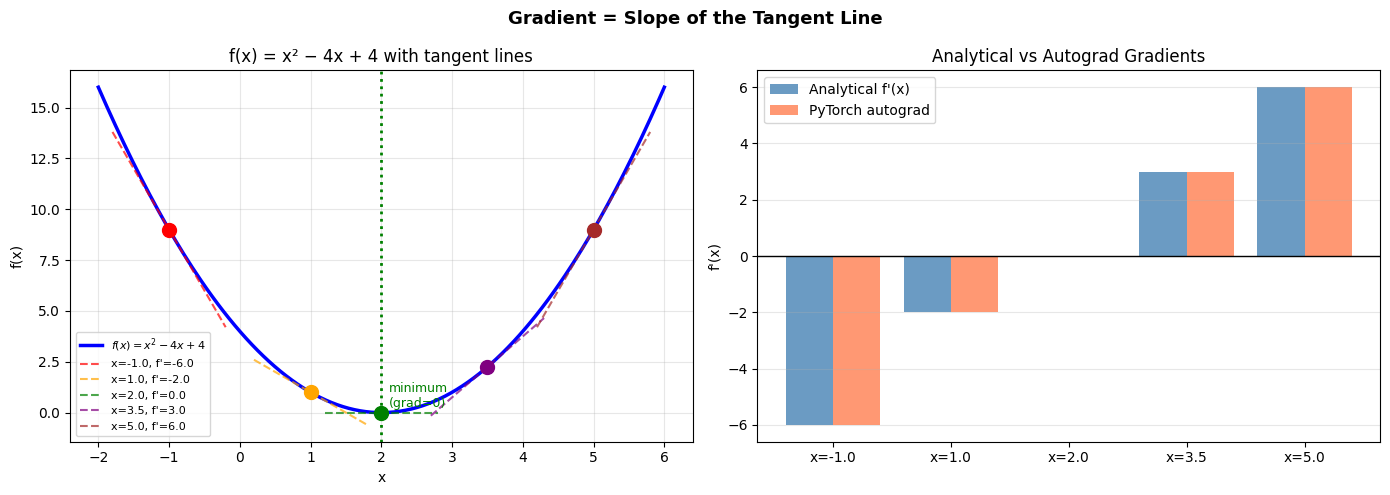


Verification table:
      x    Analytical    Autograd   Match
   -1.0       -6.0000     -6.0000       ✅
    1.0       -2.0000     -2.0000       ✅
    2.0        0.0000      0.0000       ✅
    3.5        3.0000      3.0000       ✅
    5.0        6.0000      6.0000       ✅


In [ ]:
# ─── 2.7 Interactive: Gradient as Slope Visualisation ─────────────────────
# For f(x) = x² − 4x + 4, f'(x) = 2x − 4. Minimum at x=2.
# Watch how the gradient points downhill.

xs = torch.linspace(-2, 6, 200)
ys = xs**2 - 4*xs + 4

sample_points = [-1.0, 1.0, 2.0, 3.5, 5.0]
grads_analytical = [2*xp - 4 for xp in sample_points]

# Verify with autograd
autograd_grads = []
for xp in sample_points:
    xt = torch.tensor(xp, requires_grad=True)
    ft = xt**2 - 4*xt + 4
    ft.backward()
    autograd_grads.append(xt.grad.item())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: function with tangent lines
ax1.plot(xs.numpy(), ys.numpy(), 'b-', linewidth=2.5, label=r'$f(x) = x^2 - 4x + 4$')
colours_pts = ['red', 'orange', 'green', 'purple', 'brown']

for xp, g, c in zip(sample_points, autograd_grads, colours_pts):
    yt = xp**2 - 4*xp + 4
    ax1.scatter([xp], [yt], color=c, zorder=5, s=100)
    # tangent line
    tx = np.array([xp - 0.8, xp + 0.8])
    ty = yt + g * (tx - xp)
    ax1.plot(tx, ty, '--', color=c, alpha=0.7, label=f'x={xp}, f\'={g:.1f}')

ax1.set_xlabel('x'); ax1.set_ylabel('f(x)')
ax1.set_title('f(x) = x² − 4x + 4 with tangent lines')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
ax1.axvline(x=2, color='green', linewidth=2, linestyle=':')
ax1.text(2.1, 0.3, 'minimum\n(grad=0)', color='green', fontsize=9)

# Right: analytical vs autograd
ax2.bar(np.arange(len(sample_points)) - 0.2, grads_analytical,
        width=0.4, label='Analytical f\'(x)', color='steelblue', alpha=0.8)
ax2.bar(np.arange(len(sample_points)) + 0.2, autograd_grads,
        width=0.4, label='PyTorch autograd', color='coral', alpha=0.8)
ax2.set_xticks(range(len(sample_points)))
ax2.set_xticklabels([f'x={xp}' for xp in sample_points])
ax2.set_title('Analytical vs Autograd Gradients')
ax2.set_ylabel("f'(x)")
ax2.legend(); ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(0, color='black', linewidth=1)

plt.suptitle('Gradient = Slope of the Tangent Line', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nVerification table:')
print(f'  {"x":>5}  {"Analytical":>12}  {"Autograd":>10}  {"Match":>6}')
for xp, ga, ag in zip(sample_points, grads_analytical, autograd_grads):
    print(f'  {xp:>5}  {ga:>12.4f}  {ag:>10.4f}  {"✅" if abs(ga-ag)<1e-4 else "❌":>6}')

---
# Part 3 — Backpropagation: By Hand and with Autograd 
---

## 3.1 What is Backpropagation?

**Backpropagation** is an *algorithm* for efficiently computing the gradient of a loss function with respect to **all weights** in a neural network simultaneously, using the chain rule.

It differs from simply "computing partial derivatives" in a key way:

| Plain Differentiation | Backpropagation |
|---|---|
| Computes $\partial L / \partial w_i$ one at a time | Computes **all** $\partial L / \partial w_i$ in **one backward pass** |
| No memory of intermediate structure | **Saves the computation graph**, reuses intermediate results |
| Cost grows linearly with # of parameters | Cost is proportional to forward pass cost |

## 3.2 The Key Insight: Reusing Intermediate Gradients

Consider a network where many paths feed into a single node. The graph structure lets backprop **accumulate** contributions from all paths without recomputing them.

This is the **reverse-mode automatic differentiation** (reverse-mode AD = backprop for scalar outputs).

---

## 3.3 A Tiny MLP by Hand

Let's build the simplest possible MLP and do one complete forward + backward pass manually.

**Architecture**: 2 inputs → 2 hidden neurons → 1 output  
**Activation**: Sigmoid $\sigma(x) = \frac{1}{1+e^{-x}}$  
**Loss**: Mean Squared Error $L = \frac{1}{2}(\hat{y} - y)^2$

**Forward pass**:
$$h_1 = \sigma(w_1 x_1 + w_2 x_2 + b_1)$$
$$h_2 = \sigma(w_3 x_1 + w_4 x_2 + b_2)$$
$$\hat{y} = \sigma(v_1 h_1 + v_2 h_2 + b_3)$$
$$L = \frac{1}{2}(\hat{y} - y)^2$$

**Backward pass** (chain rule all the way back):

$$\frac{\partial L}{\partial v_1} = (\hat{y} - y) \cdot \hat{y}(1-\hat{y}) \cdot h_1$$

$$\frac{\partial L}{\partial w_1} = (\hat{y} - y) \cdot \hat{y}(1-\hat{y}) \cdot v_1 \cdot h_1(1-h_1) \cdot x_1$$

In [13]:
# ─── 3.4 Manual Backprop on a Tiny MLP ────────────────────────────────────
# Architecture: 2 → 2 → 1 with sigmoid activations

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(s):
    """Derivative of sigmoid where s = sigmoid(x), so d/dx = s(1-s)"""
    return s * (1 - s)

# ── Inputs and target ────────────────────────────────────────────────────
x1, x2 = 0.05, 0.10
y_true  = 0.01   # target

# ── Weights (hidden layer) ────────────────────────────────────────────────
w1, w2, w3, w4 = 0.15, 0.20, 0.25, 0.30
b1, b2         = 0.35, 0.35

# ── Weights (output layer) ────────────────────────────────────────────────
v1, v2 = 0.40, 0.45
b3     = 0.60

# ════════════════════════════════════════════════════════
# FORWARD PASS
# ════════════════════════════════════════════════════════

# Hidden layer pre-activations
net_h1 = w1*x1 + w2*x2 + b1
net_h2 = w3*x1 + w4*x2 + b2

# Hidden layer activations
h1 = sigmoid(net_h1)
h2 = sigmoid(net_h2)

# Output layer pre-activation
net_out = v1*h1 + v2*h2 + b3

# Output activation
y_hat = sigmoid(net_out)

# Loss: MSE
L = 0.5 * (y_hat - y_true)**2

print('═' * 50)
print('  FORWARD PASS')
print('═' * 50)
print(f'  net_h1 = {net_h1:.6f}   h1 = {h1:.6f}')
print(f'  net_h2 = {net_h2:.6f}   h2 = {h2:.6f}')
print(f'  net_out = {net_out:.6f}  y_hat = {y_hat:.6f}')
print(f'  Loss L = {L:.8f}')

# ════════════════════════════════════════════════════════
# BACKWARD PASS
# ════════════════════════════════════════════════════════

# ── Output layer ──────────────────────────────────────────────────
dL_dyhat = (y_hat - y_true)                 # ∂L/∂ŷ
dyhat_dnet = sigmoid_deriv(y_hat)           # ∂ŷ/∂net_out
delta_out  = dL_dyhat * dyhat_dnet          # ∂L/∂net_out

# Gradients for output weights
dL_dv1 = delta_out * h1
dL_dv2 = delta_out * h2
dL_db3 = delta_out

# ── Hidden layer ──────────────────────────────────────────────────
# How does net_out change with h1 and h2?
dL_dh1 = delta_out * v1
dL_dh2 = delta_out * v2

# Sigmoid derivatives
dh1_dnet_h1 = sigmoid_deriv(h1)
dh2_dnet_h2 = sigmoid_deriv(h2)

delta_h1 = dL_dh1 * dh1_dnet_h1
delta_h2 = dL_dh2 * dh2_dnet_h2

# Gradients for hidden weights
dL_dw1 = delta_h1 * x1
dL_dw2 = delta_h1 * x2
dL_dw3 = delta_h2 * x1
dL_dw4 = delta_h2 * x2

print('\n' + '═' * 50)
print('  BACKWARD PASS — MANUAL')
print('═' * 50)
print(f'  δ_out  = {delta_out:.8f}')
print(f'  ∂L/∂v1 = {dL_dv1:.8f}')
print(f'  ∂L/∂v2 = {dL_dv2:.8f}')
print(f'  δ_h1   = {delta_h1:.8f}')
print(f'  δ_h2   = {delta_h2:.8f}')
print(f'  ∂L/∂w1 = {dL_dw1:.8f}')
print(f'  ∂L/∂w2 = {dL_dw2:.8f}')
print(f'  ∂L/∂w3 = {dL_dw3:.8f}')
print(f'  ∂L/∂w4 = {dL_dw4:.8f}')

══════════════════════════════════════════════════
  FORWARD PASS
══════════════════════════════════════════════════
  net_h1 = 0.377500   h1 = 0.593270
  net_h2 = 0.392500   h2 = 0.596884
  net_out = 1.105906  y_hat = 0.751365
  Loss L = 0.27481108

══════════════════════════════════════════════════
  BACKWARD PASS — MANUAL
══════════════════════════════════════════════════
  δ_out  = 0.13849856
  ∂L/∂v1 = 0.08216704
  ∂L/∂v2 = 0.08266763
  δ_h1   = 0.01336792
  δ_h2   = 0.01499608
  ∂L/∂w1 = 0.00066840
  ∂L/∂w2 = 0.00133679
  ∂L/∂w3 = 0.00074980
  ∂L/∂w4 = 0.00149961


In [14]:
# ─── 3.5 Same MLP with PyTorch Autograd — Verification ────────────────────
# We'll use the same weights and inputs and verify our manual results.

# Leaf tensors — network parameters
W1 = torch.tensor([[w1, w2],
                    [w3, w4]], dtype=torch.float64, requires_grad=True)
B1 = torch.tensor([b1, b2], dtype=torch.float64, requires_grad=True)
V1 = torch.tensor([v1, v2], dtype=torch.float64, requires_grad=True)
B3 = torch.tensor([b3], dtype=torch.float64, requires_grad=True)

X  = torch.tensor([x1, x2], dtype=torch.float64)
Y  = torch.tensor([y_true], dtype=torch.float64)

# Forward pass
H    = torch.sigmoid(W1 @ X + B1)
Yhat = torch.sigmoid(V1 @ H + B3)
Loss = 0.5 * (Yhat - Y)**2

# Backward pass
Loss.backward()

print('═' * 55)
print('  Manual vs PyTorch Autograd — Comparison')
print('═' * 55)
print(f'  Loss: {Loss.item():.8f}  (manual: {L:.8f}) ')
print(f'  ∂L/∂v1 — manual: {dL_dv1:.8f}  | autograd: {V1.grad[0].item():.8f} ')
print(f'  ∂L/∂v2 — manual: {dL_dv2:.8f}  | autograd: {V1.grad[1].item():.8f} ')
print(f'  ∂L/∂w1 — manual: {dL_dw1:.8f}  | autograd: {W1.grad[0,0].item():.8f} ')
print(f'  ∂L/∂w2 — manual: {dL_dw2:.8f}  | autograd: {W1.grad[0,1].item():.8f} ')
print(f'  ∂L/∂w3 — manual: {dL_dw3:.8f}  | autograd: {W1.grad[1,0].item():.8f} ')
print(f'  ∂L/∂w4 — manual: {dL_dw4:.8f}  | autograd: {W1.grad[1,1].item():.8f} ')

═══════════════════════════════════════════════════════
  Manual vs PyTorch Autograd — Comparison
═══════════════════════════════════════════════════════
  Loss: 0.27481108  (manual: 0.27481108) 
  ∂L/∂v1 — manual: 0.08216704  | autograd: 0.08216704 
  ∂L/∂v2 — manual: 0.08266763  | autograd: 0.08266763 
  ∂L/∂w1 — manual: 0.00066840  | autograd: 0.00066840 
  ∂L/∂w2 — manual: 0.00133679  | autograd: 0.00133679 
  ∂L/∂w3 — manual: 0.00074980  | autograd: 0.00074980 
  ∂L/∂w4 — manual: 0.00149961  | autograd: 0.00149961 


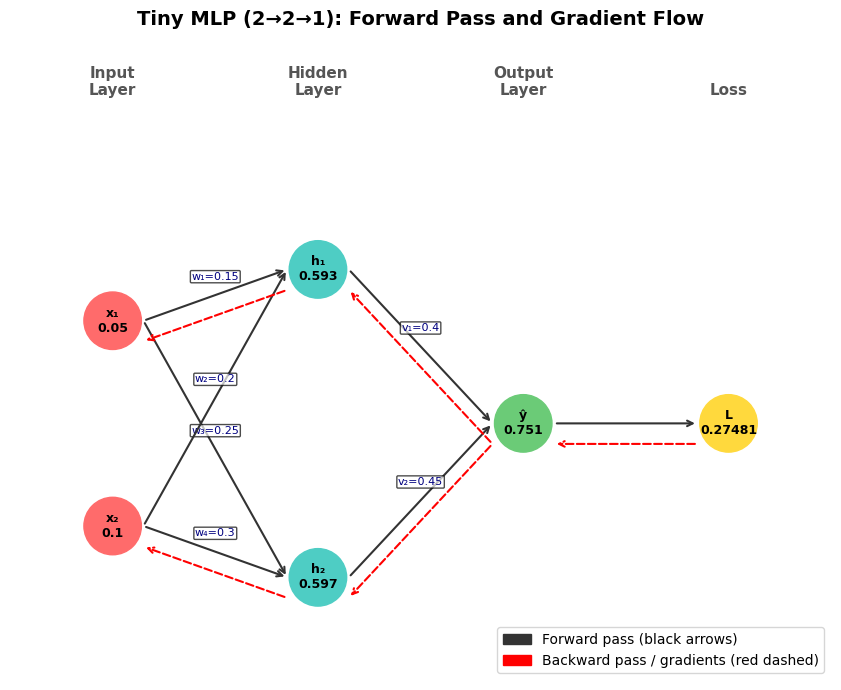

In [15]:
# ─── 3.6 Visualising the MLP and Gradient Flow ────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

# Node positions
layer_x = [1, 3, 5, 7]
positions = {
    'x1':   (1, 3.0), 'x2':   (1, 1.0),
    'h1':   (3, 3.5), 'h2':   (3, 0.5),
    'yhat': (5, 2.0),
    'L':    (7, 2.0),
}

node_labels = {
    'x1': f'x₁\n{x1}', 'x2': f'x₂\n{x2}',
    'h1': f'h₁\n{h1:.3f}', 'h2': f'h₂\n{h2:.3f}',
    'yhat': f'ŷ\n{y_hat:.3f}',
    'L':    f'L\n{L:.5f}',
}

node_cols = {'x1': '#FF6B6B', 'x2': '#FF6B6B',
             'h1': '#4ECDC4', 'h2': '#4ECDC4',
             'yhat': '#6BCB77', 'L': '#FFD93D'}

# Draw edges (forward = black, backward = red)
edges_fw = [('x1','h1'), ('x1','h2'), ('x2','h1'), ('x2','h2'),
            ('h1','yhat'), ('h2','yhat'), ('yhat','L')]

edge_weights = {
    ('x1','h1'): f'w₁={w1}', ('x2','h1'): f'w₂={w2}',
    ('x1','h2'): f'w₃={w3}', ('x2','h2'): f'w₄={w4}',
    ('h1','yhat'): f'v₁={v1}', ('h2','yhat'): f'v₂={v2}',
}

for (src, dst) in edges_fw:
    x0, y0 = positions[src]
    x1c, y1c = positions[dst]
    ax.annotate('', xy=(x1c-0.3, y1c), xytext=(x0+0.3, y0),
                arrowprops=dict(arrowstyle='->', color='#333333', lw=1.5))
    if (src,dst) in edge_weights:
        mx, my = (x0+x1c)/2, (y0+y1c)/2 + 0.15
        ax.text(mx, my, edge_weights[(src,dst)], fontsize=8,
                ha='center', color='navy',
                bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.7))

# Draw backward gradient arrows (dashed red)
grad_data = [
    ('L', 'yhat', f'∂L/∂ŷ\n{dL_dyhat:.4f}'),
    ('yhat', 'h1', f'∂L/∂h₁\n{dL_dh1:.4f}'),
    ('yhat', 'h2', f'∂L/∂h₂\n{dL_dh2:.4f}'),
    ('h1', 'x1', f'∂L/∂w₁\n{dL_dw1:.5f}'),
    ('h2', 'x2', f'∂L/∂w₄\n{dL_dw4:.5f}'),
]

for (src, dst, lbl) in grad_data:
    x0, y0 = positions[src]
    x1c, y1c = positions[dst]
    ax.annotate('', xy=(x1c+0.3, y1c-0.2), xytext=(x0-0.3, y0-0.2),
                arrowprops=dict(arrowstyle='->', color='red',
                                lw=1.5, linestyle='dashed'))

# Draw nodes
for node, (nx_pos, ny_pos) in positions.items():
    circle = plt.Circle((nx_pos, ny_pos), 0.28,
                         color=node_cols[node], zorder=5)
    ax.add_patch(circle)
    ax.text(nx_pos, ny_pos, node_labels[node],
            ha='center', va='center', fontsize=9,
            fontweight='bold', zorder=6)

# Layer labels
for x_pos, label in zip([1,3,5,7], ['Input\nLayer', 'Hidden\nLayer', 'Output\nLayer', 'Loss']):
    ax.text(x_pos, 5.2, label, ha='center', fontsize=11,
            fontweight='bold', color='#555555')

# Legend
forward_patch  = mpatches.Patch(color='#333333', label='Forward pass (black arrows)')
backward_patch = mpatches.Patch(color='red', label='Backward pass / gradients (red dashed)')
ax.legend(handles=[forward_patch, backward_patch], loc='lower right', fontsize=10)

ax.set_xlim(0, 8)
ax.set_ylim(-0.5, 5.8)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Tiny MLP (2→2→1): Forward Pass and Gradient Flow', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Part 4 — The PyTorch Toolbox 
---

PyTorch is organised into a clean set of modules. Here's the map:

| Module | What it gives you |
|---|---|
| `torch` | Core tensor operations, math, random |
| `torch.nn` | Neural network layers, activations, loss functions |
| `torch.nn.functional` | Stateless versions of NN functions |
| `torch.optim` | Optimisers (SGD, Adam, RMSProp, …) |
| `torch.utils.data` | `Dataset`, `DataLoader`, sampling |
| `torchvision` | Computer vision datasets, transforms, pre-trained models |
| `torch.cuda` | GPU management |
| `torch.onnx` | Export models to ONNX format |
| `torch.jit` | TorchScript for production deployment |

---

## 4.1 `torch.nn` — Building Blocks

The `nn.Module` class is the base for all neural networks. Key layers:

| Layer | Description |
|---|---|
| `nn.Linear(in, out)` | Fully connected layer: $y = Wx + b$ |
| `nn.Conv2d(in_ch, out_ch, k)` | 2D Convolution |
| `nn.ReLU()` | Rectified Linear Unit |
| `nn.Sigmoid()` | Sigmoid activation |
| `nn.Softmax(dim)` | Softmax over a dimension |
| `nn.BatchNorm2d(ch)` | Batch normalisation |
| `nn.Dropout(p)` | Dropout regularisation |
| `nn.MaxPool2d(k)` | Max pooling |
| `nn.Sequential` | Container: chain layers in order |

In [ ]:
# ─── 4.1.2 Building a Simple MLP with nn.Module ──────────────────────────────

class SimpleMLP(nn.Module):
    """A 3-layer MLP: input_dim → 64 → 32 → output_dim"""

    def __init__(self, input_dim, hidden1, hidden2, output_dim):
        super(SimpleMLP, self).__init__()
        # nn.Linear creates a learnable weight matrix + bias
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, output_dim)

        # Activation functions (no learnable parameters)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3)   # randomly zero 30% of neurons

    def forward(self, x):
        # Defines how data flows through the network
        x = self.relu(self.fc1(x))    # layer 1 + activation
        x = self.dropout(x)           # regularisation
        x = self.relu(self.fc2(x))    # layer 2 + activation
        x = self.fc3(x)               # output layer (no activation here)
        return x


model = SimpleMLP(input_dim=784, hidden1=64, hidden2=32, output_dim=10)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable:,}')

# Test a random forward pass
x_sample = torch.randn(8, 784)   # batch of 8, 784-dim inputs
out = model(x_sample)
print(f'\nInput shape  : {x_sample.shape}')
print(f'Output shape : {out.shape}   (8 samples, 10 class scores)')

SimpleMLP(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)

Total parameters     : 52,650
Trainable parameters : 52,650

Input shape  : torch.Size([8, 784])
Output shape : torch.Size([8, 10])   (8 samples, 10 class scores)


In [ ]:
# ─── 4.1.3 Optimisers ────────────────────────────────────────────────────────
# Optimisers update weights using computed gradients: w ← w − lr * ∂L/∂w

# Popular optimisers:
sgd   = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
adam  = optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-8)
rmsp  = optim.RMSprop(model.parameters(), lr=1e-3)
adamw = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

print('Common Optimisers:')
for name, opt in [('SGD', sgd), ('Adam', adam), ('RMSprop', rmsp), ('AdamW', adamw)]:
    print(f'  {name:<10}: {type(opt).__name__}')

# ── Standard training step ────────────────────────────────────────────────
print('\nStandard training step:')
criterion = nn.CrossEntropyLoss()

x_batch  = torch.randn(16, 784)
y_batch  = torch.randint(0, 10, (16,))  # random class labels 0-9

adam.zero_grad()              # 1. Zero out previous gradients
predictions = model(x_batch)  # 2. Forward pass
loss = criterion(predictions, y_batch)  # 3. Compute loss
loss.backward()               # 4. Backpropagation
adam.step()                   # 5. Update weights

print(f'  Loss: {loss.item():.4f}')
print('  Step complete ✅')

Common Optimisers:
  SGD       : SGD
  Adam      : Adam
  RMSprop   : RMSprop
  AdamW     : AdamW

Standard training step:
  Loss: 2.3810
  Step complete ✅


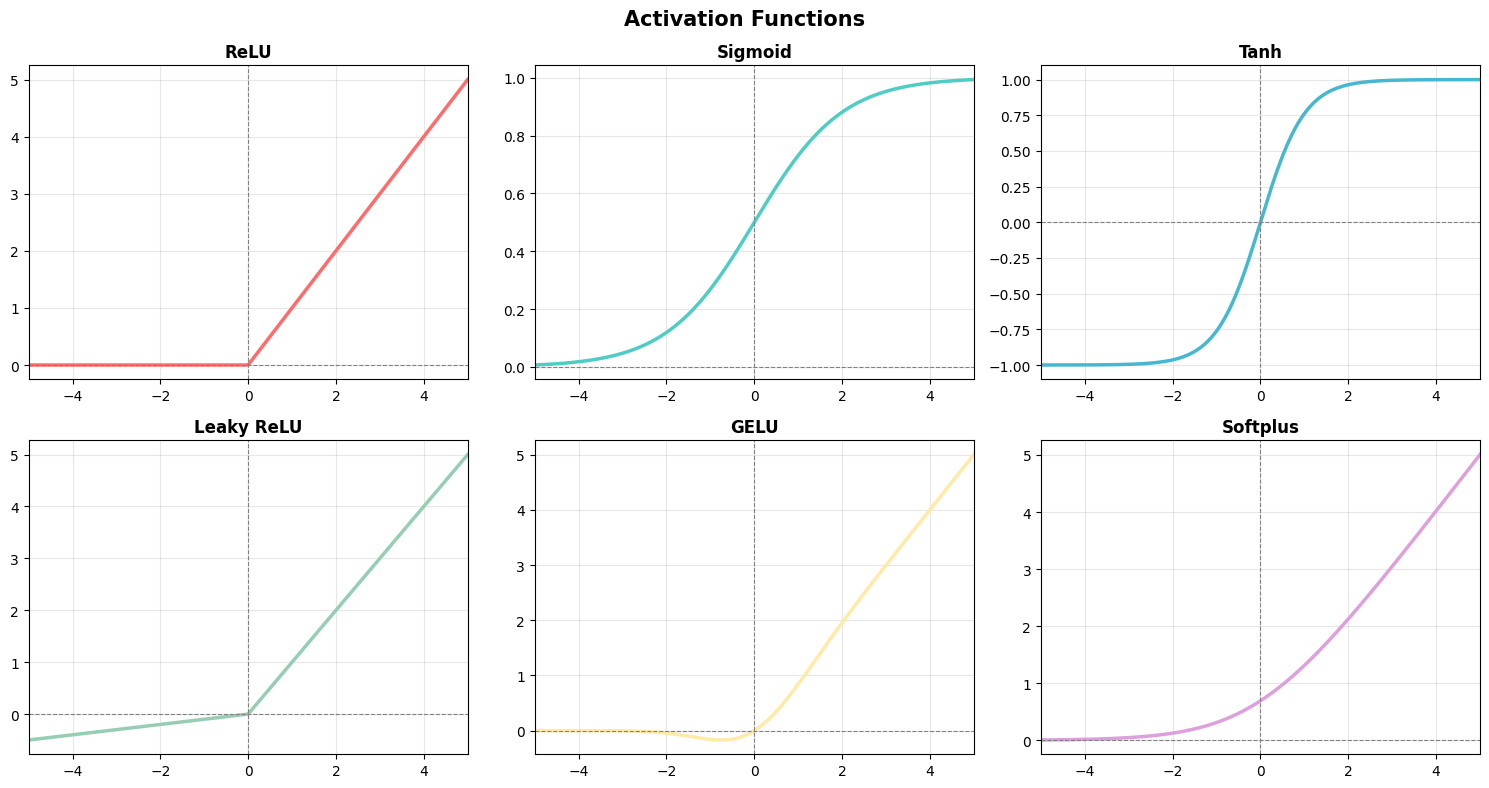

In [ ]:
# ─── 4.1.4 Common Activation Functions ──────────────────────────────────────
x = torch.linspace(-5, 5, 300)

activations = {
    'ReLU':    F.relu(x),
    'Sigmoid': torch.sigmoid(x),
    'Tanh':    torch.tanh(x),
    'Leaky ReLU': F.leaky_relu(x, 0.1),
    'GELU':    F.gelu(x),
    'Softplus': F.softplus(x),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colours_acts = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

for ax, (name, act), c in zip(axes, activations.items(), colours_acts):
    ax.plot(x.numpy(), act.numpy(), color=c, linewidth=2.5)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlim(-5, 5)
    ax.grid(True, alpha=0.3)

plt.suptitle('Activation Functions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.2 `torch.nn` —nn  vs  nn.functional  vs  Custom Modules

#
####  The core question:  torch.nn  vs  torch.nn.functional  vs  rolling your own
#### 
#


In [38]:
# 4.2.1 They are not competing — they are different *layers* of the same system.
print("=" * 65)
print(" nn vs F: the stateful vs stateless distinction")
print("=" * 65)

x = torch.randn(4, 3)   # batch of 4 samples, 3 features each

# ── nn.Linear: creates AND stores W and b internally ─────────────────────
linear_layer = nn.Linear(in_features=3, out_features=5)
out_nn = linear_layer(x)                          # just pass x, it handles W and b
print(f"\nnn.Linear output shape : {out_nn.shape}")
print(f"W stored inside layer  : {linear_layer.weight.shape}")
print(f"b stored inside layer  : {linear_layer.bias.shape}")

# ── F.linear: you supply W and b yourself ─────────────────────────────────
W = torch.randn(5, 3)   # must be (out_features, in_features)
b = torch.randn(5)
out_F = F.linear(x, W, b)                         # exact same math, no state
print(f"\nF.linear output shape  : {out_F.shape}")
print("F.linear owns nothing — W and b live outside it")

# Both compute the exact same thing: y = x @ W.T + b
# Let's prove it by using the layer's own weights in F.linear
out_verify = F.linear(x, linear_layer.weight, linear_layer.bias)
print(f"\nOutputs match when same W,b: {torch.allclose(out_nn, out_verify)}")  # True ✅


 nn vs F: the stateful vs stateless distinction

nn.Linear output shape : torch.Size([4, 5])
W stored inside layer  : torch.Size([5, 3])
b stored inside layer  : torch.Size([5])

F.linear output shape  : torch.Size([4, 5])
F.linear owns nothing — W and b live outside it

Outputs match when same W,b: True


In [40]:

# ────────────────────────────────────────────────────────────────────────────
#  SECTION 4.2.2 — The Full Comparison Table (via code)
# ────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print(" Side-by-side: same ops, two styles")
print("=" * 65)

x2d = torch.randn(2, 8, 8)      # single-channel 8x8 images, batch=2
x2d_4d = x2d.unsqueeze(1)       # (2, 1, 8, 8) — needs channel dim for conv

# ── Activations ───────────────────────────────────────────────────────────
# nn style — instantiate, then call
relu_layer    = nn.ReLU()
sigmoid_layer = nn.Sigmoid()
tanh_layer    = nn.Tanh()

x_act = torch.tensor([-2.0, -0.5, 0.0, 0.5, 2.0])

print("\n── Activations ──")
print(f"  nn.ReLU()(x)      = {relu_layer(x_act).tolist()}")
print(f"  F.relu(x)         = {F.relu(x_act).tolist()}")       # identical result
print(f"  nn.Sigmoid()(x)   = {[f'{v:.3f}' for v in sigmoid_layer(x_act).tolist()]}")
print(f"  F.sigmoid(x)      = {[f'{v:.3f}' for v in torch.sigmoid(x_act).tolist()]}")

# ── Dropout ───────────────────────────────────────────────────────────────
# ⚠️  THIS is where the difference matters most.
# nn.Dropout respects model.train() / model.eval() automatically.
# F.dropout needs you to pass training=True/False manually — easy to forget!

print("\n── Dropout ──")
dropout_layer = nn.Dropout(p=0.5)
x_drop = torch.ones(10)

dropout_layer.train()
out_train = dropout_layer(x_drop)
dropout_layer.eval()
out_eval  = dropout_layer(x_drop)

print(f"  nn.Dropout train mode : {out_train.tolist()}")   # some zeros
print(f"  nn.Dropout eval  mode : {out_eval.tolist()}")    # all ones (no dropout)

# With F.dropout you MUST pass training= yourself:
out_F_train = F.dropout(x_drop, p=0.5, training=True)
out_F_eval  = F.dropout(x_drop, p=0.5, training=False)    # must remember this!
print(f"  F.dropout training=True  : {out_F_train.tolist()}")
print(f"  F.dropout training=False : {out_F_eval.tolist()}")
print("  If you forget training=False at inference, you get random zeros in prod!")

# ── BatchNorm ─────────────────────────────────────────────────────────────
# Same story: nn.BatchNorm1d manages running_mean/var, F.batch_norm needs them
print("\n── BatchNorm ──")
bn_layer = nn.BatchNorm1d(5)                       # owns running_mean, running_var, gamma, beta
x_bn     = torch.randn(4, 5)
out_bn   = bn_layer(x_bn)
print(f"  nn.BatchNorm1d output shape : {out_bn.shape}")
print(f"  running_mean tracked        : {bn_layer.running_mean.shape}")




 Side-by-side: same ops, two styles

── Activations ──
  nn.ReLU()(x)      = [0.0, 0.0, 0.0, 0.5, 2.0]
  F.relu(x)         = [0.0, 0.0, 0.0, 0.5, 2.0]
  nn.Sigmoid()(x)   = ['0.119', '0.378', '0.500', '0.622', '0.881']
  F.sigmoid(x)      = ['0.119', '0.378', '0.500', '0.622', '0.881']

── Dropout ──
  nn.Dropout train mode : [2.0, 2.0, 2.0, 0.0, 2.0, 2.0, 0.0, 2.0, 0.0, 2.0]
  nn.Dropout eval  mode : [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  F.dropout training=True  : [2.0, 2.0, 0.0, 0.0, 0.0, 0.0, 2.0, 2.0, 2.0, 0.0]
  F.dropout training=False : [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  If you forget training=False at inference, you get random zeros in prod!

── BatchNorm ──
  nn.BatchNorm1d output shape : torch.Size([4, 5])
  running_mean tracked        : torch.Size([5])


In [43]:

# ────────────────────────────────────────────────────────────────────────────
#  SECTION 4.2.3 — WHEN TO USE WHICH
# ────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("  SECTION 3 — Decision guide: nn vs F")
print("=" * 65)

guide = """
  ─────────────────────────────────────────────────────────────
    USE nn.*  when:                                            
      ✅  The operation HAS learnable parameters             
          (Linear, Conv2d, BatchNorm, Embedding, LSTM …)       
      ✅  You want train/eval switching handled automatically   
        (Dropout, BatchNorm)                                 
      ✅  You want PyTorch to register params for the optimiser 
      ✅  Building a model class (nn.Module subclass)          
                                                              
    USE F.*  when:                                             
      ✅  The operation has NO learnable parameters            
        (relu, softmax, sigmoid, max_pool2d …)               
      ✅  You're inside a custom forward() and want brevity    
      ✅  You're writing a custom layer and manage W yourself  
      ✅  You need to dynamically change behaviour per call    
            (e.g., different dropout rates per layer)            
        Be careful with dropout/batchnorm — pass training= correctly! 
  ─────────────────────────────────────────────────────────────
"""
print(guide)


  SECTION 3 — Decision guide: nn vs F

  ─────────────────────────────────────────────────────────────
    USE nn.*  when:                                            
      ✅  The operation HAS learnable parameters             
          (Linear, Conv2d, BatchNorm, Embedding, LSTM …)       
      ✅  You want train/eval switching handled automatically   
        (Dropout, BatchNorm)                                 
      ✅  You want PyTorch to register params for the optimiser 
      ✅  Building a model class (nn.Module subclass)          

    USE F.*  when:                                             
      ✅  The operation has NO learnable parameters            
        (relu, softmax, sigmoid, max_pool2d …)               
      ✅  You're inside a custom forward() and want brevity    
      ✅  You're writing a custom layer and manage W yourself  
      ✅  You need to dynamically change behaviour per call    
            (e.g., different dropout rates per layer)            
        B

In [44]:

# ────────────────────────────────────────────────────────────────────────────
#  SECTION 4.2.4 — A PRACTICAL MODEL mixing nn and F naturally
# ────────────────────────────────────────────────────────────────────────────

print("=" * 65)
print(" Mixing nn and F in a real model")
print("=" * 65)

class MixedStyleNet(nn.Module):
    """
    A small classifier that shows exactly where nn vs F belong.
    Rule of thumb used here:
      - Layers with weights → nn.*   (registered, tracked by optimiser)
      - Pure functions      → F.*    (called inline, no state)
    """

    def __init__(self, in_features, hidden, num_classes, dropout_p=0.4):
        super().__init__()
        self.dropout_p = dropout_p           # store p so we can change it easily

        # ── Layers that OWN parameters → stored as nn attributes ──────────
        self.fc1 = nn.Linear(in_features, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, num_classes)
        self.bn1 = nn.BatchNorm1d(hidden)    # owns running stats + gamma/beta
        self.bn2 = nn.BatchNorm1d(hidden)

    def forward(self, x):
        # ── F.relu: no params, just a function — clean to call inline ─────
        x = F.relu(self.bn1(self.fc1(x)))

        # ── F.dropout: stateless, but we pass self.training automatically  ─
        # self.training is True during model.train(), False during model.eval()
        x = F.dropout(x, p=self.dropout_p, training=self.training)

        x = F.relu(self.bn2(self.fc2(x)))
        x = F.dropout(x, p=self.dropout_p, training=self.training)

        x = self.fc3(x)   # no activation on output — loss handles that

        # ── F.softmax for inspection, but CrossEntropyLoss wants raw logits ─
        # So we return logits; only apply softmax when you need probabilities
        return x

    def predict_proba(self, x):
        """Call this when you want probabilities, not logits."""
        return F.softmax(self.forward(x), dim=-1)


net = MixedStyleNet(in_features=16, hidden=32, num_classes=4)
x_test = torch.randn(8, 16)

net.train()
logits_train = net(x_test)
print(f"\nTrain mode output shape : {logits_train.shape}")

net.eval()
with torch.no_grad():
    logits_eval  = net(x_test)
    proba        = net.predict_proba(x_test)
print(f"Eval  mode output shape : {logits_eval.shape}")
print(f"Probabilities shape     : {proba.shape}")
print(f"Probabilities sum to 1  : {proba.sum(dim=-1).tolist()}")   # all ~1.0



 Mixing nn and F in a real model

Train mode output shape : torch.Size([8, 4])
Eval  mode output shape : torch.Size([8, 4])
Probabilities shape     : torch.Size([8, 4])
Probabilities sum to 1  : [0.9999999403953552, 0.9999998807907104, 1.0000001192092896, 0.9999999403953552, 0.9999999403953552, 0.9999999403953552, 1.0, 1.0000001192092896]


In [45]:

# ────────────────────────────────────────────────────────────────────────────
#  SECTION 4.2.5 — WRITING YOUR OWN CUSTOM nn.Module
# ────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("  Your own nn.Module (the easy pattern)")
print("=" * 65)

# The pattern is always the same three steps:
#   1. Subclass nn.Module
#   2. Define parameters/sub-layers in __init__
#   3. Define the computation in forward()
#
# PyTorch handles the rest: .parameters(), .to(device), .train()/.eval(),
# .state_dict(), gradient tracking — all for free.

# ── Example 1: A simple custom linear layer from scratch ─────────────────
class MyLinear(nn.Module):
    """
    Reimplements nn.Linear from scratch to show the pattern clearly.
    y = x @ W.T + b
    """

    def __init__(self, in_features, out_features, bias=True):
        super().__init__()                             # MUST call this first

        # nn.Parameter wraps a tensor and tells PyTorch:
        #   "this is a learnable weight — include it in .parameters()"
        self.W = nn.Parameter(torch.empty(out_features, in_features))
        self.b = nn.Parameter(torch.zeros(out_features)) if bias else None

        # Weight initialisation (same as PyTorch's default)
        nn.init.kaiming_uniform_(self.W, a=np.sqrt(5))

    def forward(self, x):
        # F.linear is the functional version of exactly this operation
        return F.linear(x, self.W, self.b)

    def extra_repr(self):
        """Optional: makes print(model) informative."""
        return f"in={self.W.shape[1]}, out={self.W.shape[0]}, bias={self.b is not None}"


my_lin = MyLinear(4, 6)
x_in   = torch.randn(3, 4)
out    = my_lin(x_in)
print(f"\nMyLinear output shape : {out.shape}")
print(f"Parameters tracked    : {[name for name, _ in my_lin.named_parameters()]}")
print(my_lin)



  Your own nn.Module (the easy pattern)

MyLinear output shape : torch.Size([3, 6])
Parameters tracked    : ['W', 'b']
MyLinear(in=4, out=6, bias=True)


In [ ]:
#Section 4.2.5 Continued..
# ── Example 2: A custom activation function ───────────────────────────────
class Swish(nn.Module):
    """
    Swish activation: f(x) = x * sigmoid(x)
    Used in EfficientNet. Smoother than ReLU.
    No learnable parameters — but wrapping in nn.Module lets
    you drop it into nn.Sequential cleanly.
    """

    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x * torch.sigmoid(x)    # or equivalently: F.silu(x)


# Parametric version: learnable beta
class ParametricSwish(nn.Module):
    """
    f(x) = x * sigmoid(beta * x)
    beta is a LEARNED parameter — starts at 1, network adapts it.
    """

    def __init__(self):
        super().__init__()
        self.beta = nn.Parameter(torch.ones(1))   # single learnable scalar

    def forward(self, x):
        return x * torch.sigmoid(self.beta * x)

    def extra_repr(self):
        return f"beta={self.beta.item():.4f}"


swish        = Swish()
p_swish      = ParametricSwish()
x_act2       = torch.linspace(-3, 3, 7)

print(f"\nSwish output           : {[f'{v:.3f}' for v in swish(x_act2).tolist()]}")
print(f"ParametricSwish output : {[f'{v:.3f}' for v in p_swish(x_act2).tolist()]}")
print(f"ParametricSwish beta   : {p_swish.beta.item()}")   # 1.0 initially
print(f"beta is learnable      : {p_swish.beta.requires_grad}")




Swish output           : ['-0.142', '-0.238', '-0.269', '0.000', '0.731', '1.762', '2.858']
ParametricSwish output : ['-0.142', '-0.238', '-0.269', '0.000', '0.731', '1.762', '2.858']
ParametricSwish beta   : 1.0
beta is learnable      : True


In [ ]:
#Section 4.2.5 Continued..
# ── Example 3: A custom layer with real maths — Radial Basis Function ────
class RBFLayer(nn.Module):
    """
    Radial Basis Function layer.
    Computes: output_i = exp( -||x - c_i||² / (2 * σ²) )
    where c_i are LEARNED centres and σ is a LEARNED width.

    This is something you literally cannot express as standard nn.Linear —
    a perfect case for a custom module.
    """

    def __init__(self, in_features, num_centres):
        super().__init__()
        self.centres = nn.Parameter(torch.randn(num_centres, in_features))
        self.log_sigma = nn.Parameter(torch.zeros(1))   # log for stability

    def forward(self, x):
        # x:       (batch, in_features)
        # centres: (num_centres, in_features)
        # We want pairwise squared distances: (batch, num_centres)

        # Expand for broadcasting: (batch, 1, D) - (1, K, D) → (batch, K, D)
        diff = x.unsqueeze(1) - self.centres.unsqueeze(0)
        dist_sq = (diff ** 2).sum(dim=-1)              # (batch, num_centres)

        sigma = torch.exp(self.log_sigma)              # always positive
        return torch.exp(-dist_sq / (2 * sigma ** 2))

    def extra_repr(self):
        K, D = self.centres.shape
        return f"in_features={D}, num_centres={K}, sigma={torch.exp(self.log_sigma).item():.3f}"


rbf = RBFLayer(in_features=3, num_centres=8)
x_rbf = torch.randn(5, 3)
out_rbf = rbf(x_rbf)
print(f"\nRBFLayer input  shape : {x_rbf.shape}")
print(f"RBFLayer output shape : {out_rbf.shape}   (each sample → 8 RBF responses)")
print(rbf)




RBFLayer input  shape : torch.Size([5, 3])
RBFLayer output shape : torch.Size([5, 8])   (each sample → 8 RBF responses)
RBFLayer(in_features=3, num_centres=8, sigma=1.000)


In [ ]:
#Section 4.2.5 Continued..
# ── Example 4: Custom loss function as an nn.Module ───────────────────────
class FocalLoss(nn.Module):
    """
    Focal Loss for imbalanced classification (from RetinaNet paper).
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)

    gamma > 0 reduces loss for easy examples, focuses on hard ones.
    alpha balances class frequency.

    This is pure functional logic, but wrapping in nn.Module means:
      - it prints nicely in your model summary
      - you can store and change gamma/alpha as needed
    """

    def __init__(self, gamma=2.0, alpha=0.25, reduction='mean'):
        super().__init__()
        self.gamma     = gamma
        self.alpha     = alpha
        self.reduction = reduction

    def forward(self, logits, targets):
        # logits:  (batch, num_classes) — raw scores
        # targets: (batch,) — integer class indices

        # Cross-entropy gives us -log(p_t)
        ce_loss = F.cross_entropy(logits, targets, reduction='none')

        # p_t = exp(-ce_loss)
        p_t = torch.exp(-ce_loss)

        # Focal weight: down-weights easy examples
        focal_weight = self.alpha * (1 - p_t) ** self.gamma

        focal_loss = focal_weight * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

    def extra_repr(self):
        return f"gamma={self.gamma}, alpha={self.alpha}, reduction='{self.reduction}'"


focal = FocalLoss(gamma=2.0, alpha=0.25)
logits_fl = torch.randn(8, 5)
targets_fl = torch.randint(0, 5, (8,))

fl_loss = focal(logits_fl, targets_fl)
ce_loss = F.cross_entropy(logits_fl, targets_fl)

print(f"\nFocal Loss : {fl_loss.item():.4f}")
print(f"CE Loss    : {ce_loss.item():.4f}")
print(f"Focal < CE because it down-weights easy examples: {fl_loss.item() <= ce_loss.item()}")
print(focal)




Focal Loss : 0.3457
CE Loss    : 1.8768
Focal < CE because it down-weights easy examples: True
FocalLoss(gamma=2.0, alpha=0.25, reduction='mean')


In [ ]:
#Section 4.2.5 Continued..
# ── Example 5: Compose everything into one model ──────────────────────────
print("\n" + "=" * 65)
print("  SECTION 6 — Full model using all custom components")
print("=" * 65)

class CustomNet(nn.Module):
    """
    A small network that uses our custom MyLinear, ParametricSwish,
    and standard nn / F operations — all living together naturally.
    """

    def __init__(self, in_dim, hidden, out_dim):
        super().__init__()
        self.layer1   = MyLinear(in_dim, hidden)     # our custom linear
        self.act1     = ParametricSwish()            # learnable activation
        self.bn       = nn.BatchNorm1d(hidden)       # standard nn layer
        self.layer2   = MyLinear(hidden, hidden)
        self.act2     = Swish()                      # fixed custom activation
        self.out      = nn.Linear(hidden, out_dim)   # standard nn.Linear

    def forward(self, x):
        x = self.act1(self.layer1(x))
        x = F.dropout(x, p=0.3, training=self.training)   # F for stateless ops
        x = self.bn(x)
        x = self.act2(self.layer2(x))
        x = self.out(x)
        return x


custom_net = CustomNet(in_dim=10, hidden=16, out_dim=3)
print(custom_net)

x_custom = torch.randn(6, 10)
out_custom = custom_net(x_custom)
print(f"\nOutput shape: {out_custom.shape}")

# All parameters — including from our custom layers — are tracked
total = sum(p.numel() for p in custom_net.parameters())
print(f"Total parameters tracked by PyTorch: {total}")
print("\nNamed parameters:")
for name, param in custom_net.named_parameters():
    print(f"  {name:<30} shape: {list(param.shape)}")




  SECTION 6 — Full model using all custom components
CustomNet(
  (layer1): MyLinear(in=10, out=16, bias=True)
  (act1): ParametricSwish(beta=1.0000)
  (bn): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer2): MyLinear(in=16, out=16, bias=True)
  (act2): Swish()
  (out): Linear(in_features=16, out_features=3, bias=True)
)

Output shape: torch.Size([6, 3])
Total parameters tracked by PyTorch: 532

Named parameters:
  layer1.W                       shape: [16, 10]
  layer1.b                       shape: [16]
  act1.beta                      shape: [1]
  bn.weight                      shape: [16]
  bn.bias                        shape: [16]
  layer2.W                       shape: [16, 16]
  layer2.b                       shape: [16]
  out.weight                     shape: [3, 16]
  out.bias                       shape: [3]


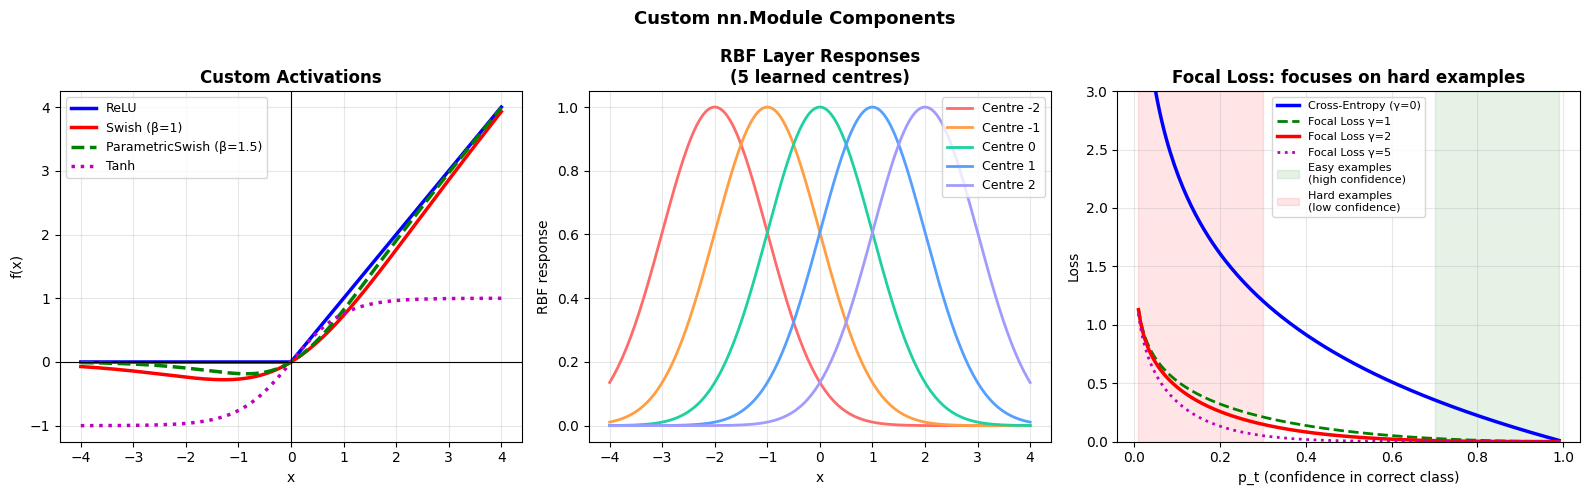

In [ ]:
#Section 4.2.5 Continued..

# ── Plot 1: Swish vs ReLU vs ParametricSwish ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
xs = torch.linspace(-4, 4, 200)

axes[0].plot(xs, F.relu(xs).numpy(),               'b-', lw=2.5, label='ReLU')
axes[0].plot(xs, swish(xs).detach().numpy(),        'r-', lw=2.5, label='Swish (β=1)')
# Simulate a "learned" beta=1.5
p_swish_15 = ParametricSwish()
p_swish_15.beta.data = torch.tensor([1.5])
axes[0].plot(xs, p_swish_15(xs).detach().numpy(),  'g--', lw=2.5, label='ParametricSwish (β=1.5)')
axes[0].plot(xs, torch.tanh(xs).numpy(),           'm:',  lw=2.5, label='Tanh')
axes[0].axhline(0, color='k', lw=0.8)
axes[0].axvline(0, color='k', lw=0.8)
axes[0].set_title('Custom Activations', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')

# ── Plot 2: RBF responses ─────────────────────────────────────────────────
rbf_1d = RBFLayer(in_features=1, num_centres=5)
# Set centres manually for clarity
rbf_1d.centres.data = torch.tensor([[-2.0], [-1.0], [0.0], [1.0], [2.0]])
rbf_1d.log_sigma.data = torch.tensor([0.0])   # sigma=1

xs_1d = torch.linspace(-4, 4, 200).unsqueeze(1)
rbf_out = rbf_1d(xs_1d).detach().numpy()

colours_rbf = ['#FF6B6B','#FF9F43','#1DD1A1','#54A0FF','#A29BFE']
for i in range(5):
    axes[1].plot(xs_1d.squeeze().numpy(), rbf_out[:, i],
                 color=colours_rbf[i], lw=2,
                 label=f'Centre {rbf_1d.centres[i].item():.0f}')
axes[1].set_title('RBF Layer Responses\n(5 learned centres)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('x'); axes[1].set_ylabel('RBF response')

# ── Plot 3: Focal Loss vs CE Loss across confidence levels ─────────────────
p_vals = np.linspace(0.01, 0.99, 200)    # p_t = predicted probability of true class
ce_vals     = -np.log(p_vals)
focal_g1    = -0.25 * (1 - p_vals)**1 * np.log(p_vals)
focal_g2    = -0.25 * (1 - p_vals)**2 * np.log(p_vals)
focal_g5    = -0.25 * (1 - p_vals)**5 * np.log(p_vals)

axes[2].plot(p_vals, ce_vals,     'b-',  lw=2.5, label='Cross-Entropy (γ=0)')
axes[2].plot(p_vals, focal_g1,    'g--', lw=2,   label='Focal Loss γ=1')
axes[2].plot(p_vals, focal_g2,    'r-',  lw=2.5, label='Focal Loss γ=2')
axes[2].plot(p_vals, focal_g5,    'm:',  lw=2,   label='Focal Loss γ=5')
axes[2].axvspan(0.7, 0.99, alpha=0.1, color='green',
                label='Easy examples\n(high confidence)')
axes[2].axvspan(0.01, 0.3, alpha=0.1, color='red',
                label='Hard examples\n(low confidence)')
axes[2].set_ylim(0, 3)
axes[2].set_title('Focal Loss: focuses on hard examples', fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlabel('p_t (confidence in correct class)')
axes[2].set_ylabel('Loss')

plt.suptitle('Custom nn.Module Components', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



In [55]:

# ────────────────────────────────────────────────────────────────────────────
#  Section 4.2 Summary
# ────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("  Section 4.2 Summary - nn.Module vs F.*")
print("=" * 65)
print("""
  ┌──────────────┬──────────────────────────────────────────────┐
  │  nn.*        │  Stateful. Owns weights. Registered as       │
  │  (classes)   │  parameters. Use for: Linear, Conv2d,        │
  │              │  BatchNorm, Dropout, Embedding, LSTM …       │
  ├──────────────┼──────────────────────────────────────────────┤
  │  F.*         │  Stateless. Just math. You pass everything   │
  │  (functions) │  in. Use for: relu, softmax, dropout (with   │
  │              │  training=), cross_entropy, interpolate …    │
  ├──────────────┼──────────────────────────────────────────────┤
  │  Custom      │  Subclass nn.Module. Wrap tensors in         │
  │  nn.Module   │  nn.Parameter. Define forward(). Get         │
  │              │  .parameters(), .to(), .train()/.eval()      │
  │              │  for FREE.                                    │
  └──────────────┴──────────────────────────────────────────────┘

  The three golden rules of custom modules:
    1. super().__init__()          — always, always first
    2. nn.Parameter(tensor)        — for any tensor you want learned
    3. define forward(self, x)     — PyTorch calls this when you do model(x)
""")


  Section 4.2 Summary - nn.Module vs F.*

  ┌──────────────┬──────────────────────────────────────────────┐
  │  nn.*        │  Stateful. Owns weights. Registered as       │
  │  (classes)   │  parameters. Use for: Linear, Conv2d,        │
  │              │  BatchNorm, Dropout, Embedding, LSTM …       │
  ├──────────────┼──────────────────────────────────────────────┤
  │  F.*         │  Stateless. Just math. You pass everything   │
  │  (functions) │  in. Use for: relu, softmax, dropout (with   │
  │              │  training=), cross_entropy, interpolate …    │
  ├──────────────┼──────────────────────────────────────────────┤
  │  Custom      │  Subclass nn.Module. Wrap tensors in         │
  │  nn.Module   │  nn.Parameter. Define forward(). Get         │
  │              │  .parameters(), .to(), .train()/.eval()      │
  │              │  for FREE.                                    │
  └──────────────┴──────────────────────────────────────────────┘

  The three golden rules of cus

---
# Part 5 — Convolutions: The Math and the Intuition 
---

## 5.1 What is a Convolution?

In the continuous world, the convolution of two functions $f$ and $g$ is:

$$(f * g)(t) = \int_{-\infty}^{\infty} f(\tau) g(t - \tau) \, d\tau$$

In the **discrete 2D** case (images), for input $I$ and kernel $K$ of size $k_h \times k_w$:

$$(I * K)(i, j) = \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} I(i+m,\; j+n) \cdot K(m, n)$$

(Note: in deep learning, this is technically **cross-correlation**, but we call it convolution by convention.)

---

## 5.2 Stride and Padding

**Stride** $s$: how many pixels the kernel moves at each step

**Padding** $p$: zeros added around the border of the input

**Output size formula** for input $H$ with kernel $k$, stride $s$, padding $p$:

$$H_{out} = \left\lfloor \frac{H + 2p - k}{s} \right\rfloor + 1$$

For the width dimension:

$$W_{out} = \left\lfloor \frac{W + 2p - k}{s} \right\rfloor + 1$$

**Common configurations**:
| | stride | padding | effect |
|---|---|---|---|
| `'valid'` | 1 | 0 | output shrinks |
| `'same'` | 1 | $\lfloor k/2 \rfloor$ | output = input size |
| Downsampling | 2 | 1 | halves spatial dims |

---

## 5.3 What Kernels Learn

Different kernels detect different features:
- **Edge detection**: Sobel, Laplacian kernels
- **Blur**: Gaussian kernel (averages neighbours)
- **Sharpen**: Subtracts blurred from original

In a CNN, **the kernels are learned** from data — the network figures out what features to look for!

In [19]:
# ─── 5.4 Manual 2D Convolution ─────────────────────────────────────────────

def conv2d_manual(image, kernel, stride=1, padding=0):
    """Manual 2D cross-correlation (what PyTorch calls Conv2d)."""
    H, W = image.shape
    kH, kW = kernel.shape

    # Add padding
    if padding > 0:
        image = np.pad(image, pad_width=padding, mode='constant', constant_values=0)
        H += 2 * padding
        W += 2 * padding

    H_out = (H - kH) // stride + 1
    W_out = (W - kW) // stride + 1

    output = np.zeros((H_out, W_out))

    for i in range(H_out):
        for j in range(W_out):
            region = image[i*stride:i*stride+kH, j*stride:j*stride+kW]
            output[i, j] = np.sum(region * kernel)   # element-wise multiply & sum

    return output


# Simple 5×5 test image
img = np.array([
    [1,  2,  3,  0,  1],
    [0,  1,  2,  3,  0],
    [1,  0,  1,  2,  1],
    [2,  1,  0,  1,  2],
    [0,  1,  2,  1,  0],
], dtype=float)

# Horizontal edge kernel
kernel_edge_h = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1],
], dtype=float)

# Blur kernel
kernel_blur = np.ones((3, 3)) / 9.0

out_edge = conv2d_manual(img, kernel_edge_h, stride=1, padding=0)
out_blur = conv2d_manual(img, kernel_blur,   stride=1, padding=0)

print(f'Input shape  : {img.shape}')
print(f'Kernel shape : (3, 3)')
print(f'Output shape : {out_edge.shape}')
print(f'Formula check: H_out = (5 - 3) / 1 + 1 = {(5-3)//1 + 1}')
print(f'\nEdge output:\n{out_edge}')
print(f'\nBlur output:\n{out_blur.round(3)}')

Input shape  : (5, 5)
Kernel shape : (3, 3)
Output shape : (3, 3)
Formula check: H_out = (5 - 3) / 1 + 1 = 3

Edge output:
[[-4. -2.  0.]
 [ 0. -4. -2.]
 [ 1.  1. -1.]]

Blur output:
[[1.222 1.556 1.444]
 [0.889 1.222 1.333]
 [0.889 1.    1.111]]


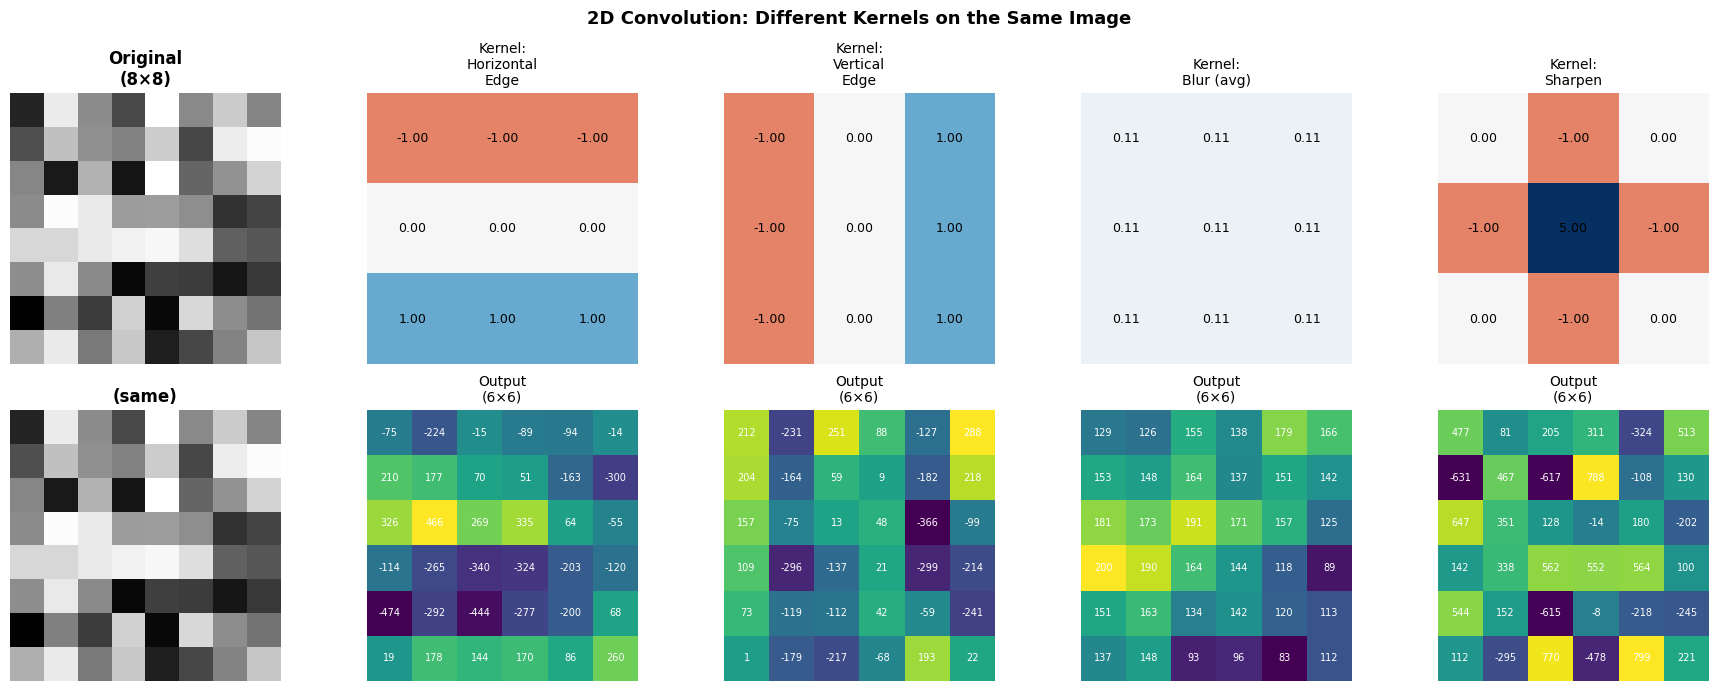

In [20]:
# ─── 5.5 Visualising Convolution Step by Step ──────────────────────────────

# Use a real image-like structure for better visualisation
np.random.seed(1)
img_big = np.random.randint(0, 256, (8, 8)).astype(float)

# Kernels to compare
kernels = {
    'Horizontal\nEdge':  np.array([[-1,-1,-1],[0,0,0],[1,1,1]]),
    'Vertical\nEdge':    np.array([[-1,0,1],[-1,0,1],[-1,0,1]]),
    'Blur (avg)':        np.ones((3,3))/9,
    'Sharpen':           np.array([[0,-1,0],[-1,5,-1],[0,-1,0]]),
}

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

# Show original
axes[0][0].imshow(img_big, cmap='gray', vmin=0, vmax=255)
axes[0][0].set_title('Original\n(8×8)', fontweight='bold')
axes[0][0].axis('off')

axes[1][0].imshow(img_big, cmap='gray', vmin=0, vmax=255)
axes[1][0].set_title('(same)', fontweight='bold')
axes[1][0].axis('off')

# Show each kernel and its output
for idx, (name, kern) in enumerate(kernels.items()):
    out = conv2d_manual(img_big, kern, stride=1, padding=0)

    # Row 0: kernel
    axes[0][idx+1].imshow(kern, cmap='RdBu', vmin=-2, vmax=2)
    for i in range(3):
        for j in range(3):
            axes[0][idx+1].text(j, i, f'{kern[i,j]:.2f}',
                                ha='center', va='center', fontsize=9)
    axes[0][idx+1].set_title(f'Kernel:\n{name}', fontsize=10)
    axes[0][idx+1].axis('off')

    # Row 1: output
    axes[1][idx+1].imshow(out, cmap='viridis')
    axes[1][idx+1].set_title(f'Output\n(6×6)', fontsize=10)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            axes[1][idx+1].text(j, i, f'{out[i,j]:.0f}',
                                ha='center', va='center',
                                fontsize=7, color='white')
    axes[1][idx+1].axis('off')

plt.suptitle('2D Convolution: Different Kernels on the Same Image', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# ─── 5.6 Shape Calculations with PyTorch nn.Conv2d ─────────────────────────
# Formula: H_out = floor((H + 2p - k) / s) + 1

def conv_output_shape(H, W, k, s=1, p=0):
    H_out = (H + 2*p - k) // s + 1
    W_out = (W + 2*p - k) // s + 1
    return H_out, W_out

print('Shape calculations for Conv2d:')
print(f'  {"Input":>15}  {"Kernel":>8}  {"Stride":>7}  {"Pad":>5}  {"Output":>12}')
print('  ' + '-'*60)

configs = [
    ((32,32), 3, 1, 0,  'No padding (valid)'),
    ((32,32), 3, 1, 1,  'Same padding'),
    ((32,32), 3, 2, 1,  'Stride-2 downsample'),
    ((64,64), 5, 1, 2,  '5×5 same'),
    ((64,64), 1, 1, 0,  '1×1 convolution'),
    ((28,28), 3, 2, 0,  'MNIST-like input'),
]

for (H,W), k, s, p, desc in configs:
    Ho, Wo = conv_output_shape(H, W, k, s, p)
    print(f'  {str((H,W)):>15}  {str((k,k)):>8}  {s:>7}  {p:>5}  ({Ho},{Wo:3})   {desc}')

# Verify with PyTorch
print('\nVerification with PyTorch nn.Conv2d:')
inp = torch.randn(1, 1, 32, 32)    # batch=1, channels=1, H=32, W=32
conv_valid = nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=0)
conv_same  = nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1)
conv_down  = nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1)

with torch.no_grad():
    print(f'  Input (1,1,32,32) → conv(k=3,s=1,p=0) → {conv_valid(inp).shape}')
    print(f'  Input (1,1,32,32) → conv(k=3,s=1,p=1) → {conv_same(inp).shape}')
    print(f'  Input (1,1,32,32) → conv(k=3,s=2,p=1) → {conv_down(inp).shape}')

Shape calculations for Conv2d:
            Input    Kernel   Stride    Pad        Output
  ------------------------------------------------------------
         (32, 32)    (3, 3)        1      0  (30, 30)   No padding (valid)
         (32, 32)    (3, 3)        1      1  (32, 32)   Same padding
         (32, 32)    (3, 3)        2      1  (16, 16)   Stride-2 downsample
         (64, 64)    (5, 5)        1      2  (64, 64)   5×5 same
         (64, 64)    (1, 1)        1      0  (64, 64)   1×1 convolution
         (28, 28)    (3, 3)        2      0  (13, 13)   MNIST-like input

Verification with PyTorch nn.Conv2d:
  Input (1,1,32,32) → conv(k=3,s=1,p=0) → torch.Size([1, 8, 30, 30])
  Input (1,1,32,32) → conv(k=3,s=1,p=1) → torch.Size([1, 8, 32, 32])
  Input (1,1,32,32) → conv(k=3,s=2,p=1) → torch.Size([1, 8, 16, 16])


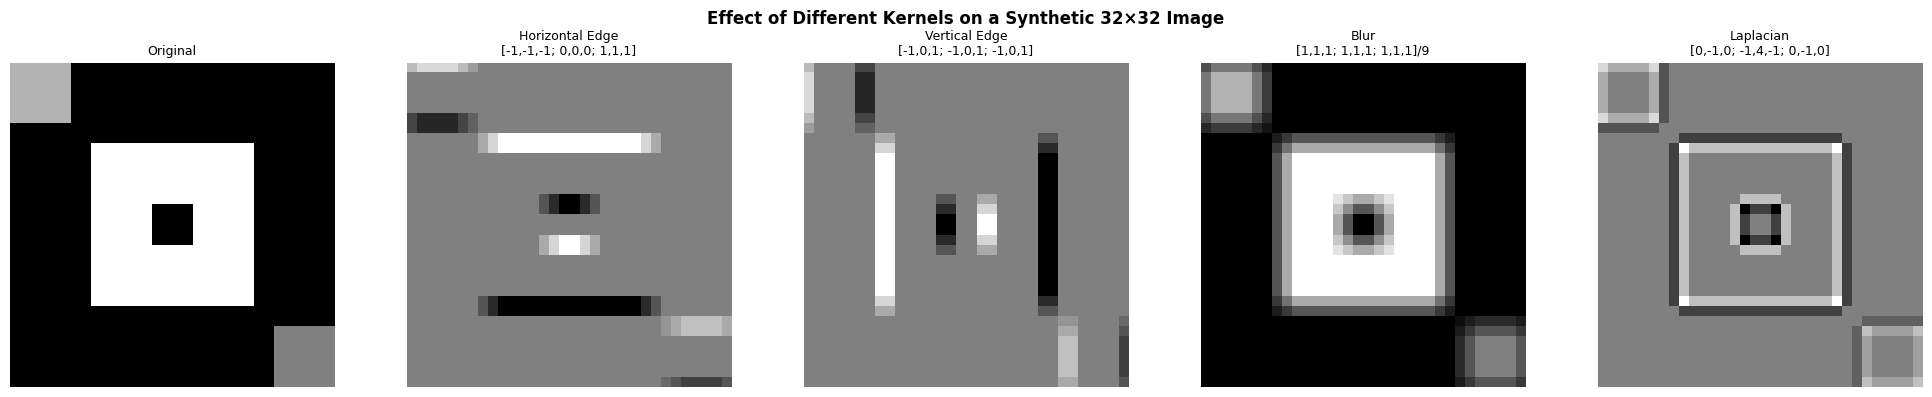

In [22]:
# ─── 5.7 Convolution on a Real Image (from torchvision) ────────────────────
# Download a sample image from CIFAR-10 preview

# We'll synthesise a simple 32×32 test image with shapes
test_img = np.zeros((32, 32), dtype=np.float32)
test_img[8:24, 8:24] = 1.0          # white square
test_img[14:18, 14:18] = 0.0         # hole in middle
test_img[0:6, 0:6] = 0.7             # corner square
test_img[26:32, 26:32] = 0.5         # another corner

# Convert to PyTorch tensor: (1, 1, H, W) — batch=1, channels=1
img_tensor = torch.tensor(test_img).unsqueeze(0).unsqueeze(0)

# Define kernels as Conv2d weights
def apply_kernel(img_t, kernel_np, pad=0):
    k = torch.tensor(kernel_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    return F.conv2d(img_t, k, padding=pad).squeeze().numpy()

kernels_to_show = [
    ('Original', None),
    ('Horizontal Edge\n[-1,-1,-1; 0,0,0; 1,1,1]',
     np.array([[-1.,-1.,-1.],[0.,0.,0.],[1.,1.,1.]])/3),
    ('Vertical Edge\n[-1,0,1; -1,0,1; -1,0,1]',
     np.array([[-1.,0.,1.],[-1.,0.,1.],[-1.,0.,1.]])/3),
    ('Blur\n[1,1,1; 1,1,1; 1,1,1]/9',
     np.ones((3,3))/9),
    ('Laplacian\n[0,-1,0; -1,4,-1; 0,-1,0]',
     np.array([[0.,-1.,0.],[-1.,4.,-1.],[0.,-1.,0.]])),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (name, kern) in zip(axes, kernels_to_show):
    if kern is None:
        result = test_img
    else:
        result = apply_kernel(img_tensor, kern, pad=1)

    ax.imshow(result, cmap='gray')
    ax.set_title(name, fontsize=9)
    ax.axis('off')

plt.suptitle('Effect of Different Kernels on a Synthetic 32×32 Image',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Part 6 — Building a CNN for CIFAR-10 from Scratch 
---

## 6.1 CIFAR-10 Dataset

CIFAR-10 is a benchmark image classification dataset:
- **60,000 images** total: 50,000 train, 10,000 test
- **10 classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
- **Image size**: 32 × 32 × 3 (small colour images)

## 6.2 Our CNN Architecture

```
Input:  (B, 3, 32, 32)
  │
  ├─ Conv2d(3→32, k=3, p=1)   → (B, 32, 32, 32)   + BN + ReLU
  ├─ Conv2d(32→32, k=3, p=1)  → (B, 32, 32, 32)   + BN + ReLU
  ├─ MaxPool2d(2)              → (B, 32, 16, 16)
  ├─ Dropout(0.25)
  │
  ├─ Conv2d(32→64, k=3, p=1)  → (B, 64, 16, 16)   + BN + ReLU
  ├─ Conv2d(64→64, k=3, p=1)  → (B, 64, 16, 16)   + BN + ReLU
  ├─ MaxPool2d(2)              → (B, 64, 8, 8)
  ├─ Dropout(0.25)
  │
  ├─ Flatten                  → (B, 64*8*8) = (B, 4096)
  ├─ Linear(4096 → 512)       + ReLU + Dropout(0.5)
  └─ Linear(512 → 10)         (logits)
```

In [23]:
# ─── 6.3 Load and Explore CIFAR-10 ────────────────────────────────────────
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

# ── Data transforms ────────────────────────────────────────────────────────
# Training: augment with random flips + crops to prevent overfitting
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),           # randomly mirror images
    transforms.RandomCrop(32, padding=4),        # random 32×32 crop with 4px pad
    transforms.ToTensor(),                       # PIL image → float tensor [0,1]
    transforms.Normalize((0.4914, 0.4822, 0.4465),   # subtract channel mean
                          (0.2023, 0.1994, 0.2010)),  # divide by std
])

# Test: no augmentation, just normalise
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                          (0.2023, 0.1994, 0.2010)),
])

# Download datasets (downloads to ./data on first run)
print('Downloading CIFAR-10 ...')
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform)

# DataLoaders: handles batching, shuffling, parallel loading
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train samples : {len(train_dataset):,}')
print(f'Test samples  : {len(test_dataset):,}')
print(f'Train batches : {len(train_loader)}')
print(f'Test batches  : {len(test_loader)}')

# Peek at a batch
images, labels = next(iter(train_loader))
print(f'\nBatch shape   : {images.shape}  (B, C, H, W)')
print(f'Labels shape  : {labels.shape}')

100%|██████████| 170M/170M [00:17<00:00, 9.49MB/s] 


Train samples : 50,000
Test samples  : 10,000
Train batches : 391
Test batches  : 40

Batch shape   : torch.Size([128, 3, 32, 32])  (B, C, H, W)
Labels shape  : torch.Size([128])


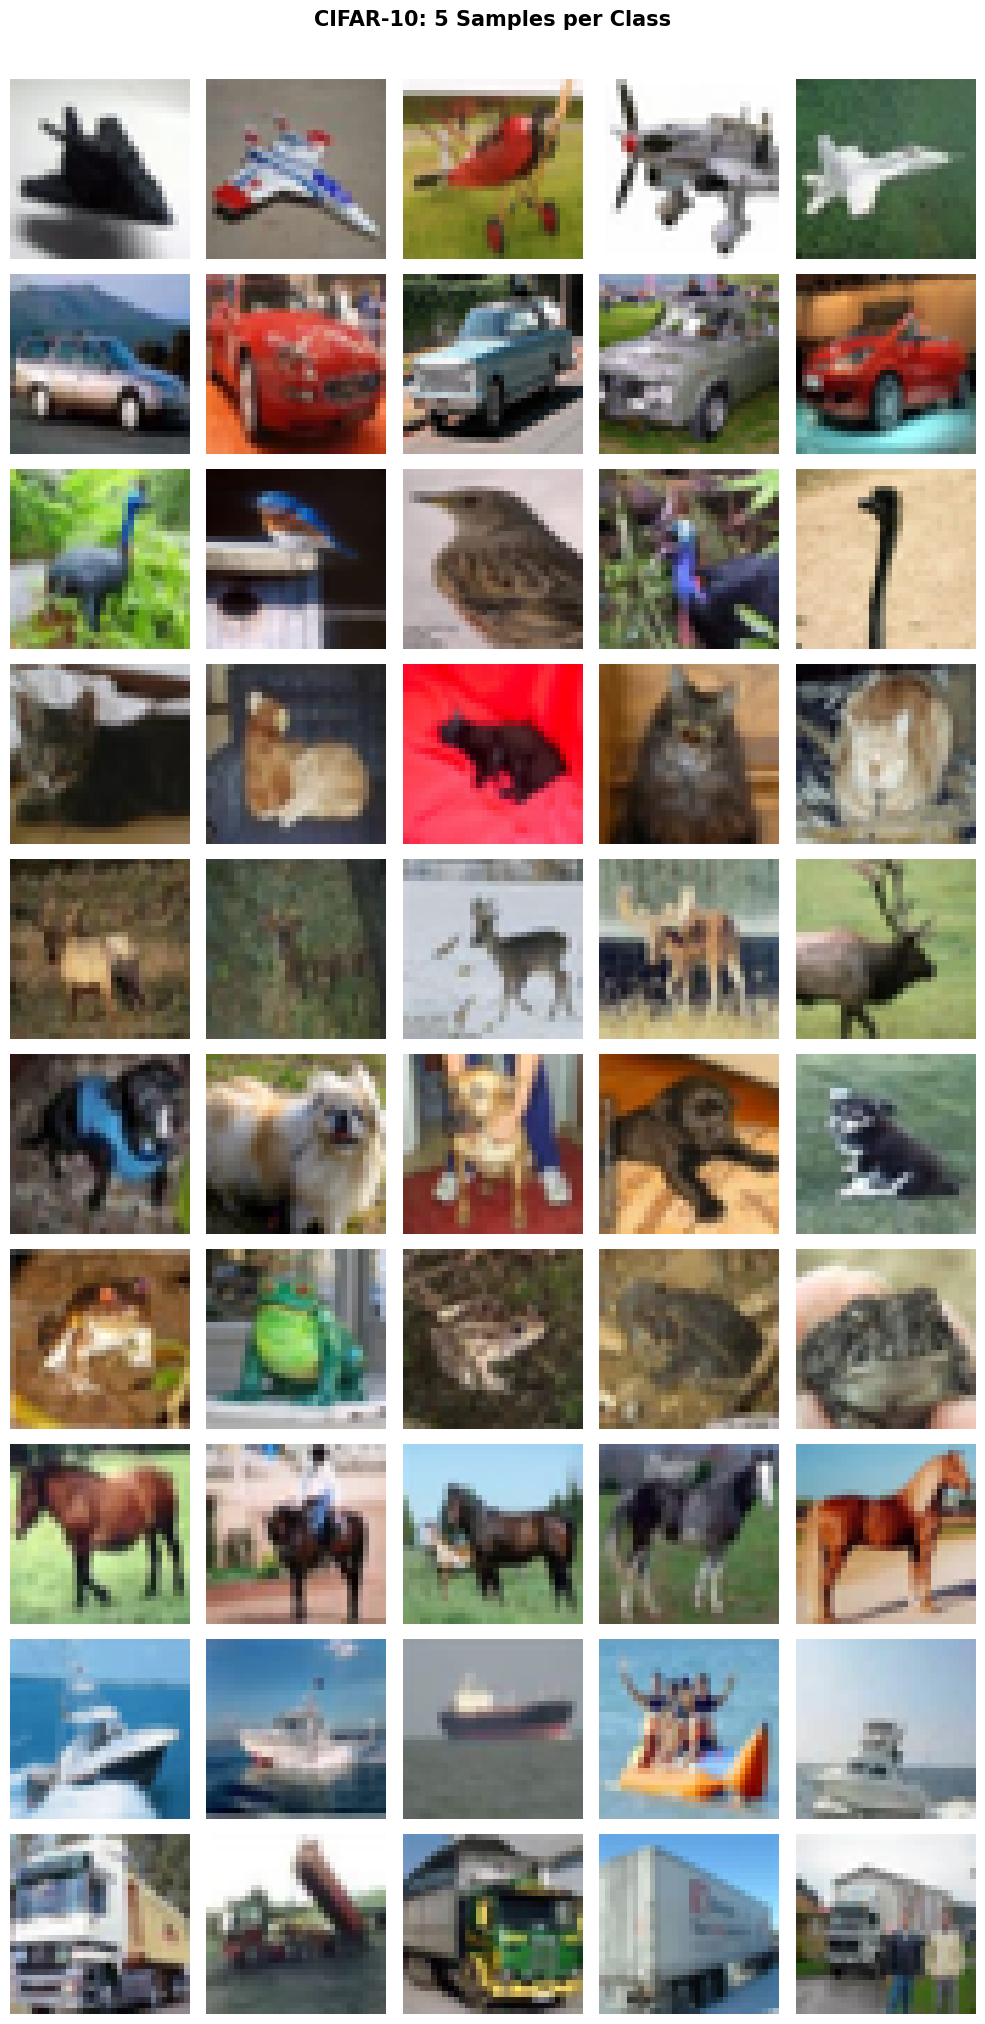

In [24]:
# ─── 6.4 Visualise Sample Images ───────────────────────────────────────────
# Load without normalisation for better display
raw_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False,
    transform=transforms.ToTensor())

# Show 5 images from each class
class_images = {i: [] for i in range(10)}
for img, lbl in raw_dataset:
    if len(class_images[lbl]) < 5:
        class_images[lbl].append(img)
    if all(len(v) == 5 for v in class_images.values()):
        break

fig, axes = plt.subplots(10, 5, figsize=(10, 20))
for class_idx in range(10):
    for img_idx in range(5):
        ax = axes[class_idx][img_idx]
        img = class_images[class_idx][img_idx].permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.axis('off')
        if img_idx == 0:
            ax.set_ylabel(CIFAR10_CLASSES[class_idx], rotation=90,
                          fontsize=11, fontweight='bold', labelpad=10)
            ax.yaxis.set_label_position('left')

plt.suptitle('CIFAR-10: 5 Samples per Class', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [25]:
# ─── 6.5 CNN Architecture ──────────────────────────────────────────────────

class CIFAR10_CNN(nn.Module):
    """
    A clean CNN for CIFAR-10 with two conv blocks followed by FC layers.

    Architecture:
        Input  (B, 3, 32, 32)
        Block1 → (B, 32, 16, 16)  [two conv layers + maxpool]
        Block2 → (B, 64, 8,  8)   [two conv layers + maxpool]
        FC     → (B, 512) → (B, 10)
    """

    def __init__(self, num_classes=10):
        super(CIFAR10_CNN, self).__init__()

        # ── BLOCK 1: extract low-level features (edges, textures) ───────
        self.block1 = nn.Sequential(
            # 3 input channels (RGB) → 32 feature maps
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),      # normalise each channel across the batch
            nn.ReLU(inplace=True),

            # 32 → 32, same spatial size
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # Halve spatial dimensions: 32×32 → 16×16
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.25),    # randomly zero entire feature maps
        )

        # ── BLOCK 2: extract higher-level features (shapes, objects) ────
        self.block2 = nn.Sequential(
            # 32 → 64, same spatial size
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # 64 → 64, same spatial size
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # Halve: 16×16 → 8×8
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.25),
        )

        # ── CLASSIFIER HEAD: global features → class scores ─────────────
        self.classifier = nn.Sequential(
            nn.Flatten(),                      # (B, 64, 8, 8) → (B, 4096)
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),                 # strong regularisation at FC
            nn.Linear(512, num_classes),       # 512 → 10 class logits
        )

        # Weight initialisation (He / Kaiming for ReLU networks)
        self._init_weights()

    def _init_weights(self):
        """Kaiming init for conv layers, xavier for linear."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.block1(x)        # feature extraction: low-level
        x = self.block2(x)        # feature extraction: high-level
        x = self.classifier(x)   # classification
        return x                  # returns raw logits (no softmax — CrossEntropyLoss handles that)


# Instantiate and move to device
cnn = CIFAR10_CNN(num_classes=10).to(DEVICE)
print(cnn)

total_p     = sum(p.numel() for p in cnn.parameters())
trainable_p = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f'\nTotal parameters     : {total_p:,}')
print(f'Trainable parameters : {trainable_p:,}')

# Shape trace
dummy = torch.randn(1, 3, 32, 32).to(DEVICE)
print('\nShape trace:')
print(f'  Input         : {dummy.shape}')
with torch.no_grad():
    b1 = cnn.block1(dummy)
    b2 = cnn.block2(b1)
    out = cnn.classifier(b2)
print(f'  After block1  : {b1.shape}')
print(f'  After block2  : {b2.shape}')
print(f'  After FC head : {out.shape}')

CIFAR10_CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=

In [26]:
# ─── 6.6 Training the CNN ──────────────────────────────────────────────────

# Loss: CrossEntropyLoss = log-softmax + NLL loss
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)  # slight label smoothing

# Optimiser: AdamW with weight decay
optimizer = optim.AdamW(cnn.parameters(), lr=1e-3, weight_decay=1e-4)

# Learning rate scheduler: cosine annealing (lr decays smoothly)
NUM_EPOCHS = 25
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)


def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch. Returns (avg_loss, accuracy)."""
    model.train()      # activates dropout & batchnorm training mode
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()              # clear old gradients
        logits = model(images)             # forward pass
        loss   = criterion(logits, labels) # compute loss
        loss.backward()                    # backprop

        # Gradient clipping: prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()                   # update weights

        total_loss += loss.item() * images.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, 100.0 * correct / total


@torch.no_grad()   # decorator: no grad tracking for efficiency
def evaluate(model, loader, criterion, device):
    """Evaluate on a data loader. Returns (avg_loss, accuracy)."""
    model.eval()     # turns off dropout & uses running stats in batchnorm
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, 100.0 * correct / total


# ── Training loop ─────────────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f'Training on {DEVICE} for {NUM_EPOCHS} epochs ...')
print(f'{"Epoch":>6}  {"Tr Loss":>9}  {"Tr Acc":>8}  {"Val Loss":>10}  {"Val Acc":>9}  {"LR":>10}')
print('-' * 65)

best_val_acc = 0.0
best_state   = None

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(cnn, train_loader, criterion, optimizer, DEVICE)
    va_loss, va_acc = evaluate(cnn, test_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)

    # Save best model checkpoint
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state   = {k: v.clone() for k, v in cnn.state_dict().items()}
        star = ' ⭐'
    else:
        star = ''

    current_lr = scheduler.get_last_lr()[0]
    print(f'{epoch:>6}  {tr_loss:>9.4f}  {tr_acc:>7.2f}%  {va_loss:>10.4f}  {va_acc:>8.2f}%  {current_lr:>10.6f}{star}')

print(f'\nBest validation accuracy: {best_val_acc:.2f}%')

# Load best weights back
if best_state:
    cnn.load_state_dict(best_state)
    print('Best model weights restored ')

Training on cpu for 25 epochs ...
 Epoch    Tr Loss    Tr Acc    Val Loss    Val Acc          LR
-----------------------------------------------------------------
     1     2.0036    29.33%      1.5762     46.37%    0.000996 ⭐
     2     1.7560    37.84%      1.4657     51.65%    0.000984 ⭐
     3     1.6823    41.33%      1.3734     55.87%    0.000965 ⭐
     4     1.6198    44.54%      1.3193     57.49%    0.000938 ⭐
     5     1.5656    46.97%      1.2479     60.25%    0.000905 ⭐
     6     1.5210    48.94%      1.2150     63.14%    0.000864 ⭐
     7     1.4829    50.88%      1.1758     63.95%    0.000819 ⭐
     8     1.4567    52.29%      1.1252     66.86%    0.000768 ⭐
     9     1.4240    53.59%      1.1250     66.51%    0.000713
    10     1.4042    54.82%      1.0905     68.32%    0.000655 ⭐
    11     1.3781    56.52%      1.0741     69.38%    0.000594 ⭐
    12     1.3548    57.28%      1.0605     69.72%    0.000531 ⭐
    13     1.3414    58.12%      1.0578     69.87%    0.000

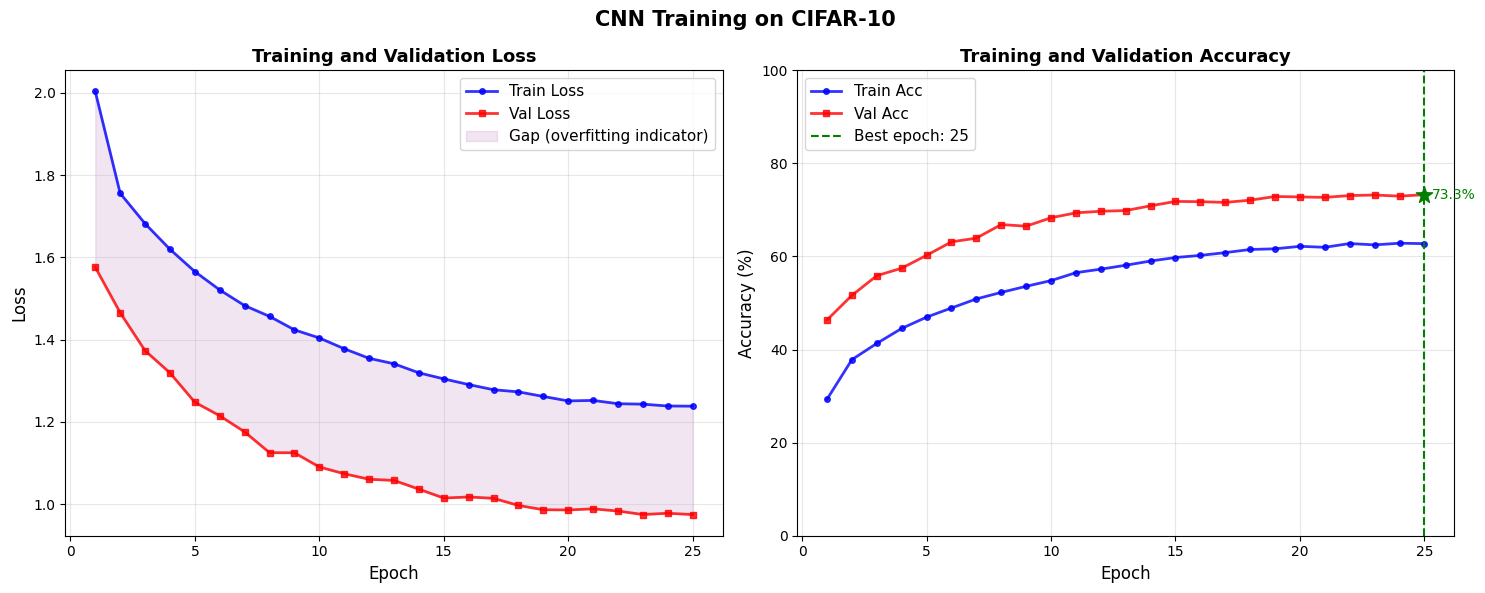

In [27]:
# ─── 6.7 Plot Training Curves ──────────────────────────────────────────────
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Loss curves
ax1.plot(epochs, history['train_loss'], 'b-o', markersize=4,
         linewidth=2, label='Train Loss', alpha=0.8)
ax1.plot(epochs, history['val_loss'], 'r-s', markersize=4,
         linewidth=2, label='Val Loss', alpha=0.8)
ax1.fill_between(epochs, history['train_loss'], history['val_loss'],
                 alpha=0.1, color='purple', label='Gap (overfitting indicator)')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(epochs, history['train_acc'], 'b-o', markersize=4,
         linewidth=2, label='Train Acc', alpha=0.8)
ax2.plot(epochs, history['val_acc'], 'r-s', markersize=4,
         linewidth=2, label='Val Acc', alpha=0.8)

# Mark best epoch
best_epoch = history['val_acc'].index(max(history['val_acc'])) + 1
ax2.axvline(x=best_epoch, color='green', linestyle='--', linewidth=1.5,
            label=f'Best epoch: {best_epoch}')
ax2.scatter([best_epoch], [best_val_acc], color='green', zorder=5, s=150, marker='*')
ax2.text(best_epoch + 0.3, best_val_acc - 1,
         f'{best_val_acc:.1f}%', color='green', fontsize=10)

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 100])

plt.suptitle('CNN Training on CIFAR-10', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

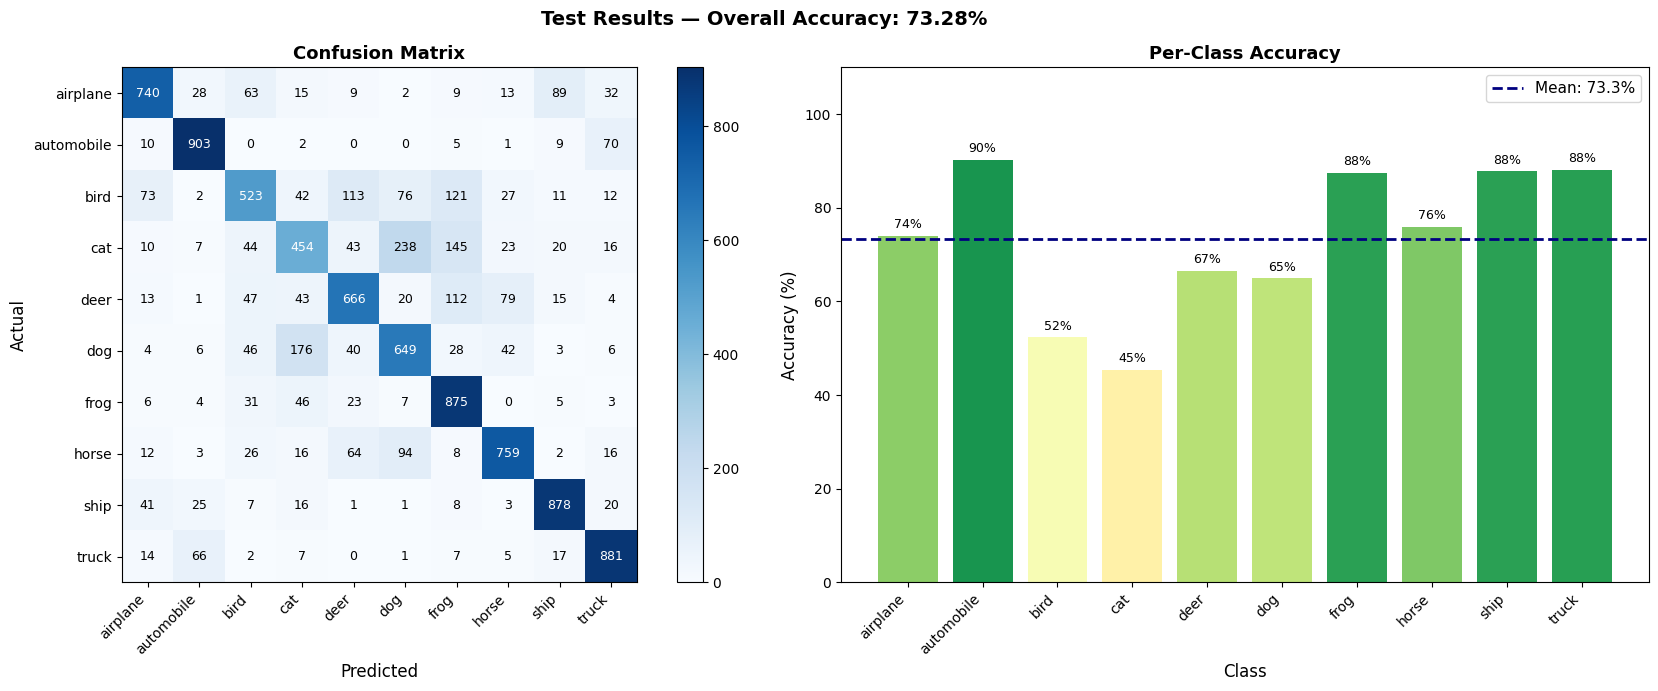

In [28]:
# ─── 6.8 Confusion Matrix ──────────────────────────────────────────────────
all_preds, all_labels = [], []

cnn.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        logits = cnn(images)
        preds  = logits.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Build confusion matrix manually
conf_matrix = np.zeros((10, 10), dtype=int)
for t, p in zip(all_labels, all_preds):
    conf_matrix[t, p] += 1

# Per-class accuracy
per_class_acc = conf_matrix.diagonal() / conf_matrix.sum(axis=1) * 100

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Confusion matrix
im = ax1.imshow(conf_matrix, cmap='Blues')
plt.colorbar(im, ax=ax1)
ax1.set_xticks(range(10))
ax1.set_yticks(range(10))
ax1.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha='right', fontsize=10)
ax1.set_yticklabels(CIFAR10_CLASSES, fontsize=10)
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('Actual', fontsize=12)
ax1.set_title('Confusion Matrix', fontsize=13, fontweight='bold')

for i in range(10):
    for j in range(10):
        txt = str(conf_matrix[i, j])
        colour = 'white' if conf_matrix[i,j] > conf_matrix.max()*0.5 else 'black'
        ax1.text(j, i, txt, ha='center', va='center',
                 fontsize=9, color=colour)

# Per-class bar chart
colours_bar = plt.cm.RdYlGn(per_class_acc / 100)
bars = ax2.bar(CIFAR10_CLASSES, per_class_acc, color=colours_bar)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_xlabel('Class', fontsize=12)
ax2.set_title('Per-Class Accuracy', fontsize=13, fontweight='bold')
ax2.set_ylim([0, 110])
ax2.axhline(y=np.mean(per_class_acc), color='navy', linewidth=2,
            linestyle='--', label=f'Mean: {np.mean(per_class_acc):.1f}%')
ax2.legend(fontsize=11)
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
for bar, acc in zip(bars, per_class_acc):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.0f}%', ha='center', va='bottom', fontsize=9)

overall_acc = (all_preds == all_labels).mean() * 100
plt.suptitle(f'Test Results — Overall Accuracy: {overall_acc:.2f}%',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

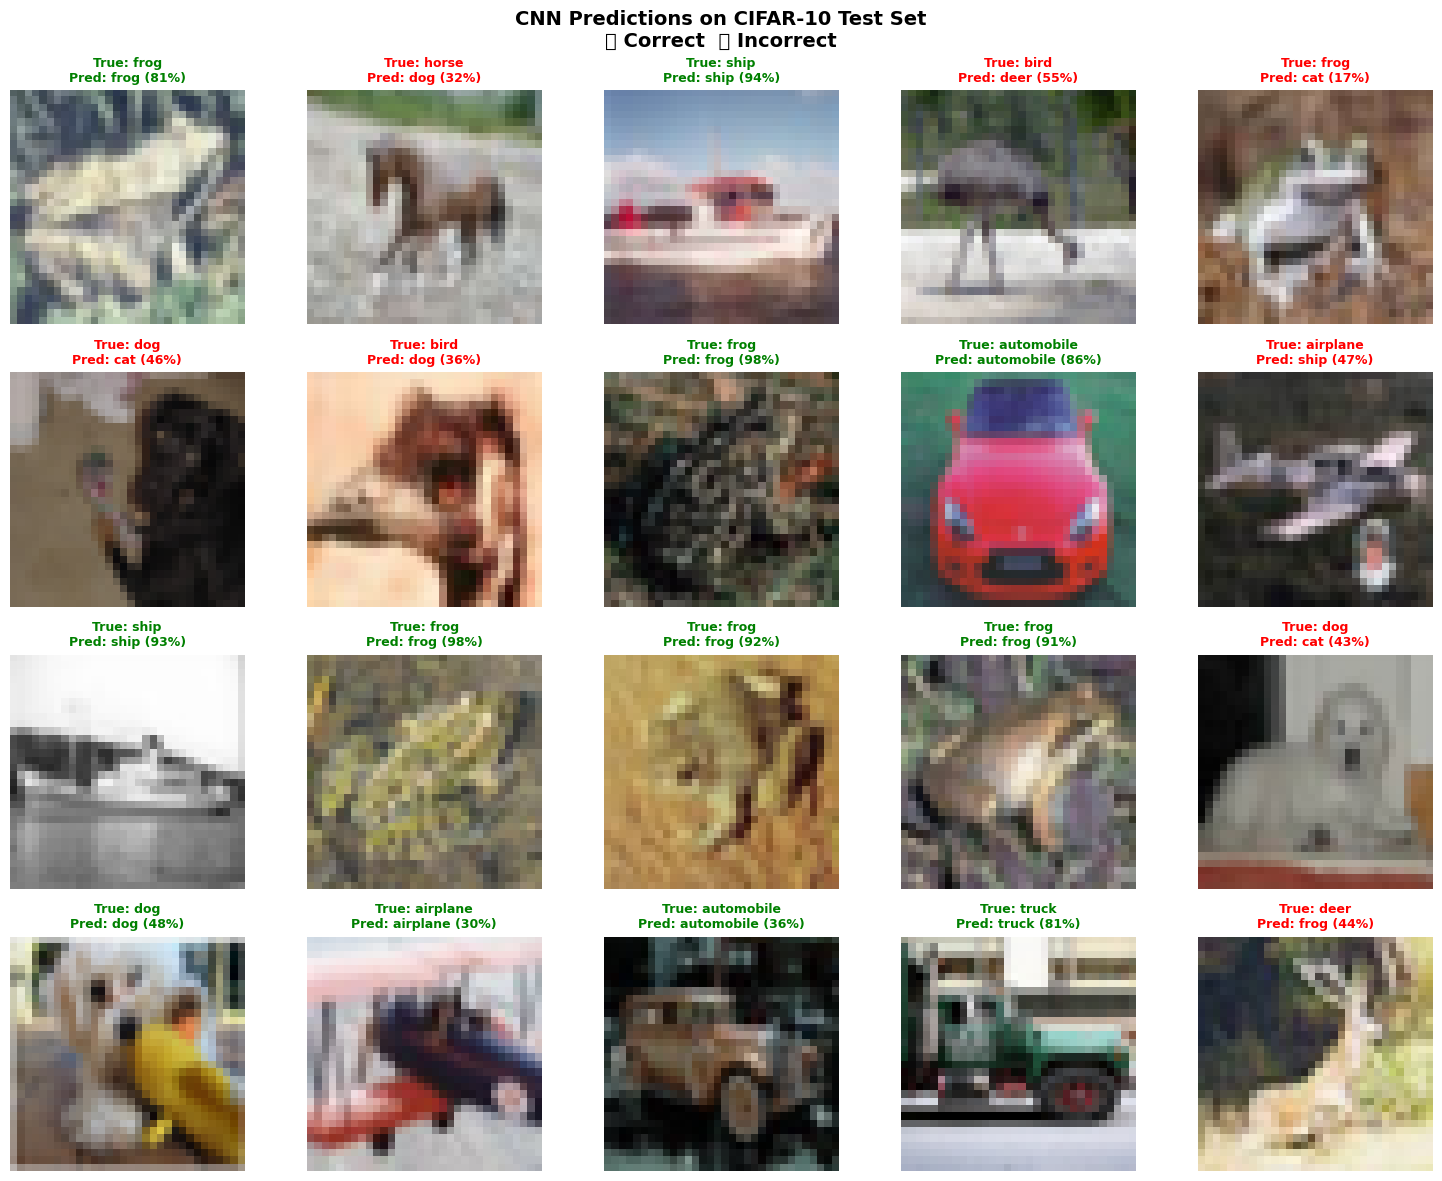

In [29]:
# ─── 6.9 Visualise Predictions on Test Images ─────────────────────────────
raw_test = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False,
    transform=transforms.ToTensor())

# Grab 20 random test images
indices = np.random.choice(len(raw_test), 20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

cnn.eval()
with torch.no_grad():
    for ax, idx in zip(axes, indices):
        raw_img, true_lbl = raw_test[idx]

        # Get normalised version for prediction
        norm_img, _ = test_dataset[idx]
        inp  = norm_img.unsqueeze(0).to(DEVICE)
        logit = cnn(inp)
        probs = F.softmax(logit, dim=1).squeeze()
        pred_lbl = probs.argmax().item()
        confidence = probs.max().item() * 100

        # Show image
        ax.imshow(raw_img.permute(1, 2, 0).numpy())

        # Title: green if correct, red if wrong
        correct = pred_lbl == true_lbl
        c = 'green' if correct else 'red'
        ax.set_title(
            f'True: {CIFAR10_CLASSES[true_lbl]}\n'
            f'Pred: {CIFAR10_CLASSES[pred_lbl]} ({confidence:.0f}%)',
            color=c, fontsize=9, fontweight='bold'
        )
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor(c)
            spine.set_linewidth(3)
            spine.set_visible(True)

plt.suptitle('CNN Predictions on CIFAR-10 Test Set\n🟢 Correct  🔴 Incorrect',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

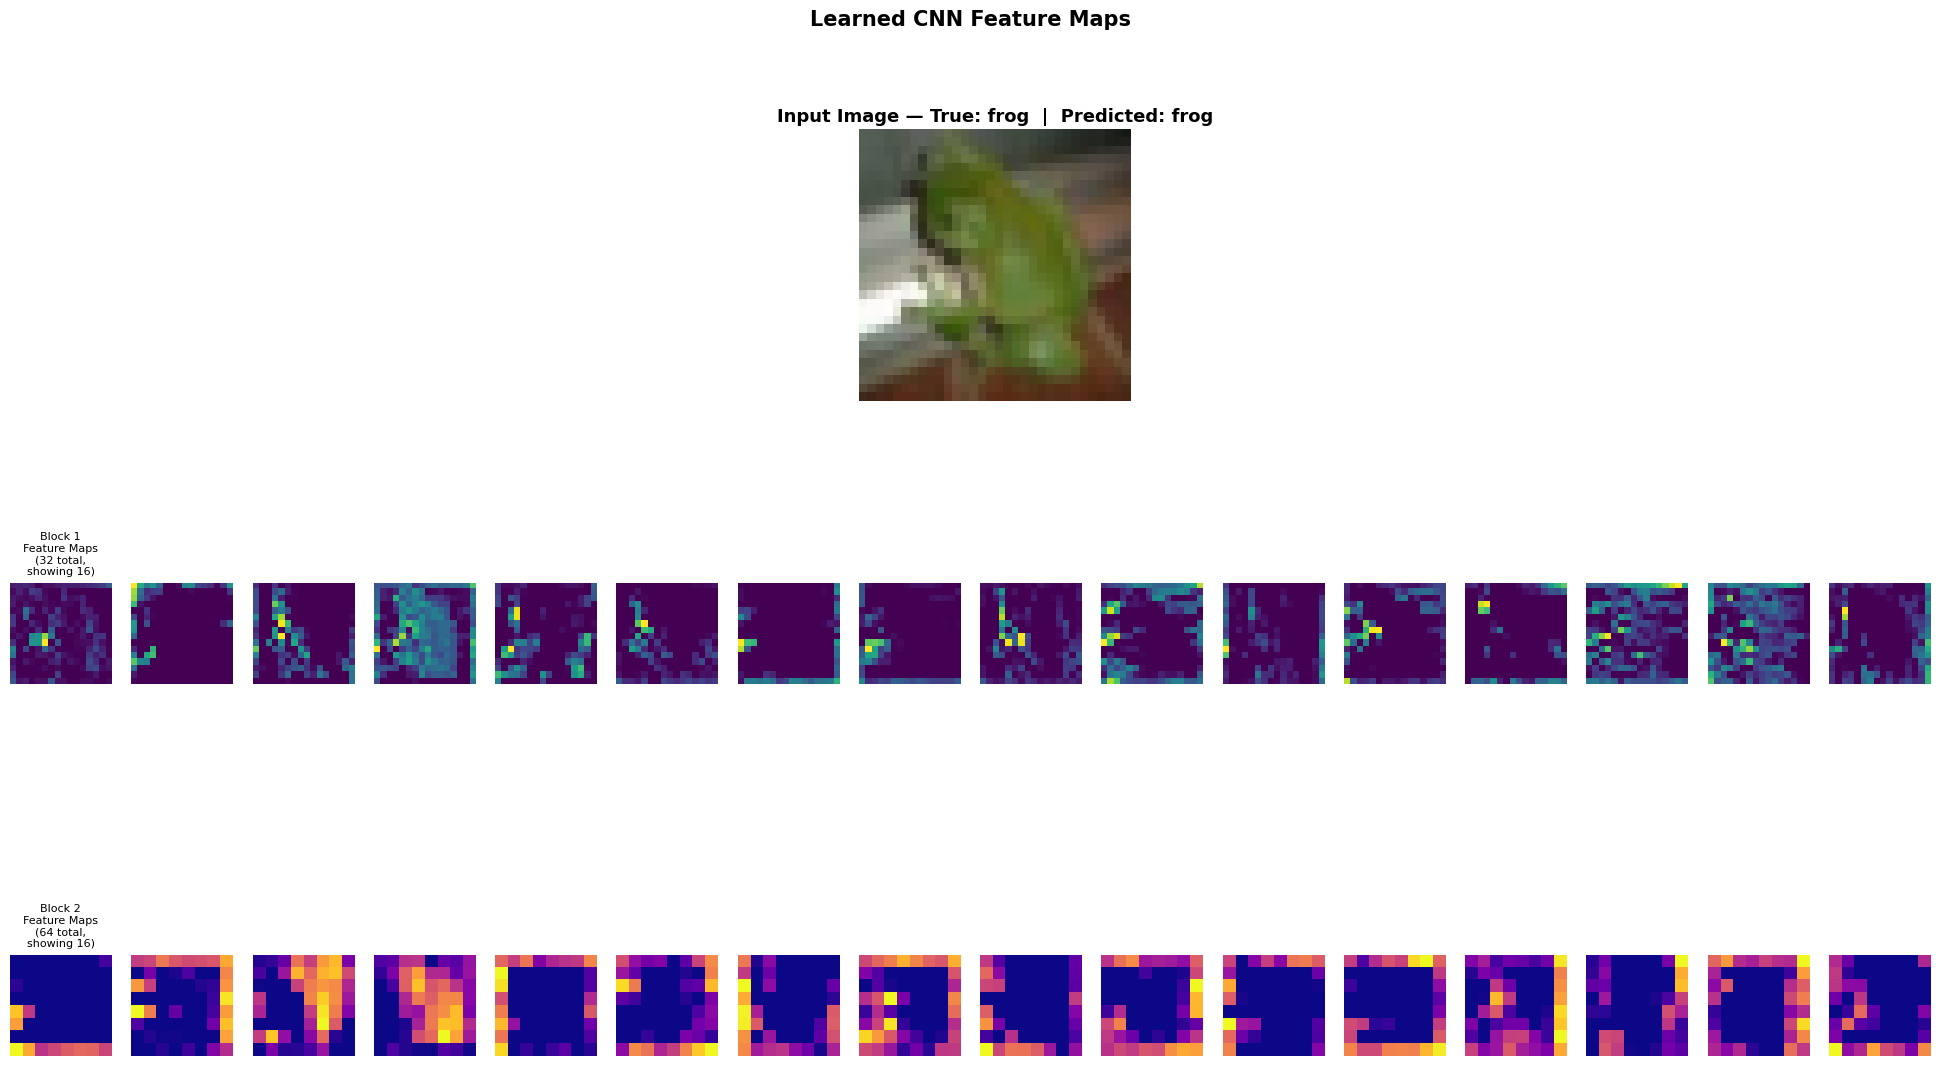

In [30]:
# ─── 6.10 Visualise Learned Feature Maps (What the CNN Sees) ───────────────
# Pick one test image and show what each layer activates on

raw_img_disp, true_lbl = raw_test[7]
norm_img_inp, _         = test_dataset[7]

inp = norm_img_inp.unsqueeze(0).to(DEVICE)

# Extract feature maps after each block using hooks
feature_maps = {}

def make_hook(name):
    def hook(module, input, output):
        feature_maps[name] = output.detach().cpu()
    return hook

h1 = cnn.block1.register_forward_hook(make_hook('block1'))
h2 = cnn.block2.register_forward_hook(make_hook('block2'))

cnn.eval()
with torch.no_grad():
    out = cnn(inp)

h1.remove(); h2.remove()

pred_class = F.softmax(out, dim=1).argmax().item()

# Visualise
fig = plt.figure(figsize=(20, 12))

# Original image
ax0 = fig.add_subplot(3, 1, 1)
ax0.imshow(raw_img_disp.permute(1,2,0).numpy())
ax0.set_title(
    f'Input Image — True: {CIFAR10_CLASSES[true_lbl]}  |  '
    f'Predicted: {CIFAR10_CLASSES[pred_class]}',
    fontsize=13, fontweight='bold')
ax0.axis('off')

# Block 1 feature maps (show first 16)
gs1 = gridspec.GridSpec(1, 16, figure=fig,
                         left=0.02, right=0.98,
                         top=0.60, bottom=0.32)
fm1 = feature_maps['block1'][0]   # (32, 16, 16)
for i in range(16):
    ax = fig.add_subplot(gs1[0, i])
    ax.imshow(fm1[i].numpy(), cmap='viridis')
    ax.axis('off')
    if i == 0:
        ax.set_title('Block 1\nFeature Maps\n(32 total,\nshowing 16)', fontsize=8)

# Block 2 feature maps (show first 16)
gs2 = gridspec.GridSpec(1, 16, figure=fig,
                         left=0.02, right=0.98,
                         top=0.28, bottom=0.02)
fm2 = feature_maps['block2'][0]   # (64, 8, 8)
for i in range(16):
    ax = fig.add_subplot(gs2[0, i])
    ax.imshow(fm2[i].numpy(), cmap='plasma')
    ax.axis('off')
    if i == 0:
        ax.set_title('Block 2\nFeature Maps\n(64 total,\nshowing 16)', fontsize=8)

plt.suptitle('Learned CNN Feature Maps', fontsize=15, fontweight='bold', y=0.98)
plt.show()

---
# Part 7 — Important Extras and PyTorch Best Practices 
---

## 7.1 Saving and Loading Models

PyTorch gives you two options:
- **`state_dict`** (recommended): saves only weights, not architecture
- **Full model**: saves everything but tightly couples to code structure

In [31]:
# ─── 7.2 Save and Load a Model ─────────────────────────────────────────────

# ── Save ──────────────────────────────────────────────────────────────────
checkpoint = {
    'epoch':      NUM_EPOCHS,
    'model_state': cnn.state_dict(),
    'optim_state': optimizer.state_dict(),
    'val_acc':     best_val_acc,
}
torch.save(checkpoint, 'cifar10_cnn.pth')
print('Model saved to cifar10_cnn.pth ')

# ── Load ──────────────────────────────────────────────────────────────────
loaded_ckpt = torch.load('cifar10_cnn.pth', map_location=DEVICE)

new_model = CIFAR10_CNN().to(DEVICE)
new_model.load_state_dict(loaded_ckpt['model_state'])
new_model.eval()

print(f'Loaded model from epoch {loaded_ckpt["epoch"]} '
      f'with val acc {loaded_ckpt["val_acc"]:.2f}% ')

# Verify it produces the same outputs
dummy_inp = torch.randn(4, 3, 32, 32).to(DEVICE)
with torch.no_grad():
    out_orig = cnn(dummy_inp)
    out_load = new_model(dummy_inp)
print(f'Outputs match: {torch.allclose(out_orig, out_load)} ')

Model saved to cifar10_cnn.pth 
Loaded model from epoch 25 with val acc 73.28% 
Outputs match: True 


In [32]:
# ─── 7.3 Transfer Learning with Pretrained Models ─────────────────────────
# PyTorch + torchvision give you access to dozens of pretrained models.
# Strategy: load a pre-trained backbone, replace the classifier head.

from torchvision.models import resnet18, ResNet18_Weights

# Load ResNet-18 pre-trained on ImageNet
resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# ── Option 1: Fine-tune everything ────────────────────────────────────────
resnet_full = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
resnet_full.fc = nn.Linear(512, 10)   # replace 1000-class head with 10-class

# ── Option 2: Freeze backbone, train only the head (feature extraction) ──
resnet_frozen = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Freeze all layers
for param in resnet_frozen.parameters():
    param.requires_grad = False

# Replace and unfreeze head only
resnet_frozen.fc = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 10)
)
# The new fc layers have requires_grad=True by default

trainable_full   = sum(p.numel() for p in resnet_full.parameters() if p.requires_grad)
trainable_frozen = sum(p.numel() for p in resnet_frozen.parameters() if p.requires_grad)

print('Transfer Learning Options:')
print(f'  Fine-tune all       : {trainable_full:>10,} trainable params')
print(f'  Head only (frozen)  : {trainable_frozen:>10,} trainable params')
print(f'  Our custom CNN      : {trainable_p:>10,} trainable params')
print('\n💡 Use "frozen" when you have little data.')
print('   Use "fine-tune all" when you have enough data and compute.')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\spothapragada/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 73.4MB/s]


Transfer Learning Options:
  Fine-tune all       : 11,181,642 trainable params
  Head only (frozen)  :    133,898 trainable params
  Our custom CNN      :  2,168,554 trainable params

💡 Use "frozen" when you have little data.
   Use "fine-tune all" when you have enough data and compute.


In [33]:
# ─── 7.4 BatchNorm and Dropout: train vs eval mode ────────────────────────
# This is one of the most common bugs in PyTorch!

print('BatchNorm + Dropout behaviour:')
print('  model.train() → dropout ACTIVE, batchnorm uses BATCH statistics')
print('  model.eval()  → dropout OFF,    batchnorm uses RUNNING statistics')
print()

# Demonstrate the difference
demo_model = nn.Sequential(
    nn.Linear(4, 8),
    nn.BatchNorm1d(8),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(8, 2)
)

x_demo = torch.randn(6, 4)

demo_model.train()
out_train1 = demo_model(x_demo)
out_train2 = demo_model(x_demo)

demo_model.eval()
with torch.no_grad():
    out_eval1 = demo_model(x_demo)
    out_eval2 = demo_model(x_demo)

print(f'  train() mode — two forward passes identical? {torch.allclose(out_train1, out_train2)}')
print(f'  eval()  mode — two forward passes identical? {torch.allclose(out_eval1, out_eval2)}')
print()
print('  Always call model.eval() before inference!')
print('  Always call model.train() before your training loop!')

BatchNorm + Dropout behaviour:
  model.train() → dropout ACTIVE, batchnorm uses BATCH statistics
  model.eval()  → dropout OFF,    batchnorm uses RUNNING statistics

  train() mode — two forward passes identical? False
  eval()  mode — two forward passes identical? True

  Always call model.eval() before inference!
  Always call model.train() before your training loop!


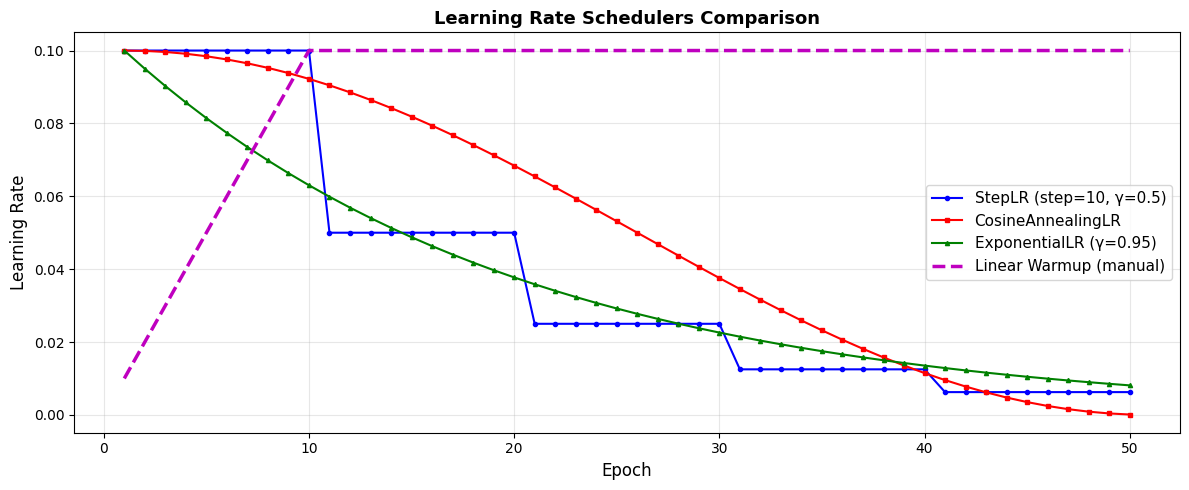

In [34]:
# ─── 7.5 Learning Rate Schedulers — Visual Comparison ─────────────────────
epochs_lr = range(1, 51)

# We'll simulate each scheduler on a dummy model
def get_lr_history(scheduler_fn):
    m = nn.Linear(2, 2)
    opt = optim.SGD(m.parameters(), lr=0.1)
    sched = scheduler_fn(opt)
    lrs = []
    for _ in epochs_lr:
        lrs.append(opt.param_groups[0]['lr'])
        sched.step()
    return lrs

lr_step    = get_lr_history(lambda o: optim.lr_scheduler.StepLR(o, step_size=10, gamma=0.5))
lr_cosine  = get_lr_history(lambda o: optim.lr_scheduler.CosineAnnealingLR(o, T_max=50))
lr_exp     = get_lr_history(lambda o: optim.lr_scheduler.ExponentialLR(o, gamma=0.95))
lr_warmup  = [min(1.0, e/10) * 0.1 for e in range(1, 51)]   # manual warmup example

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(epochs_lr, lr_step,   'b-o', markersize=3, label='StepLR (step=10, γ=0.5)')
ax.plot(epochs_lr, lr_cosine, 'r-s', markersize=3, label='CosineAnnealingLR')
ax.plot(epochs_lr, lr_exp,    'g-^', markersize=3, label='ExponentialLR (γ=0.95)')
ax.plot(epochs_lr, lr_warmup, 'm--', linewidth=2.5, label='Linear Warmup (manual)')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title('Learning Rate Schedulers Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# ─── 7.6 Custom Dataset and DataLoader ────────────────────────────────────
# Extend torch.utils.data.Dataset for any custom data source

from torch.utils.data import Dataset

class SyntheticDataset(Dataset):
    """
    A simple synthetic dataset for demonstration.
    Each sample is (feature_vector, class_label).
    """

    def __init__(self, num_samples=1000, num_features=20, num_classes=5):
        super().__init__()
        torch.manual_seed(42)

        # Generate random features and labels
        self.X = torch.randn(num_samples, num_features)   # (1000, 20)
        self.y = torch.randint(0, num_classes, (num_samples,))  # labels 0-4

        # Optionally: add class-specific signal
        for c in range(num_classes):
            mask = (self.y == c)
            self.X[mask] += c * 0.5   # shift class c features

    def __len__(self):
        """Required: return total number of samples."""
        return len(self.y)

    def __getitem__(self, idx):
        """Required: return one (sample, label) pair by index."""
        return self.X[idx], self.y[idx]


# Usage
synth = SyntheticDataset(num_samples=500, num_features=10, num_classes=3)
loader = DataLoader(synth, batch_size=32, shuffle=True)

print(f'Dataset size: {len(synth)}')
xb, yb = next(iter(loader))
print(f'Batch X shape: {xb.shape}')
print(f'Batch y shape: {yb.shape}')
print(f'Unique labels in batch: {yb.unique()}')

Dataset size: 500
Batch X shape: torch.Size([32, 10])
Batch y shape: torch.Size([32])
Unique labels in batch: tensor([0, 1, 2])


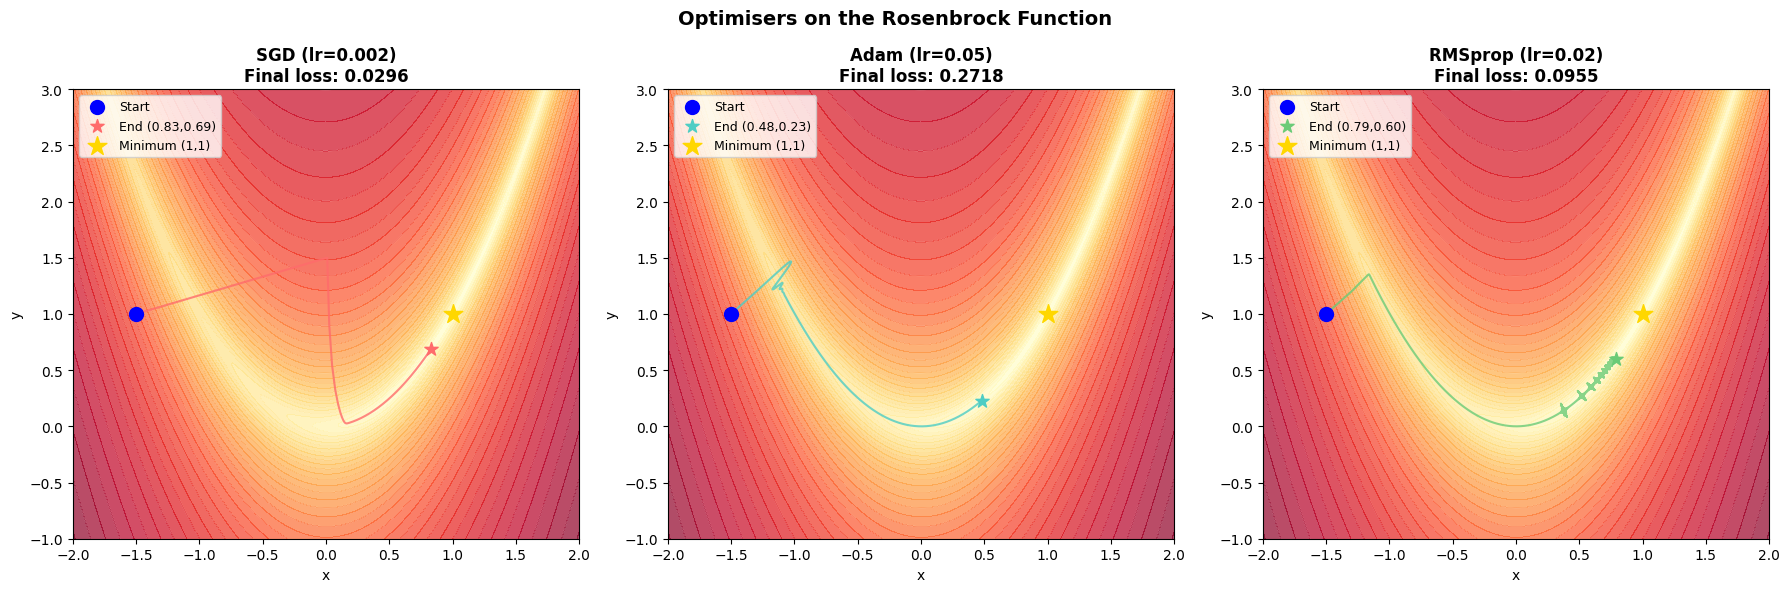

In [36]:
# ─── 7.7 Gradient Descent: Intuition with a Loss Landscape ────────────────
# Visualise how SGD, Adam find the minimum of a 2D function

def rosenbrock(x, y, a=1, b=100):
    """Rosenbrock function — classic optimisation test case.
    Minimum at (a, a²) = (1, 1)."""
    return (a - x)**2 + b*(y - x**2)**2

def optimise_2d(optimizer_name, steps=500, lr=0.001):
    """Optimise the Rosenbrock function from the same starting point."""
    x = torch.tensor([-1.5], requires_grad=True)
    y = torch.tensor([1.0],  requires_grad=True)

    if optimizer_name == 'SGD':
        opt = optim.SGD([x, y], lr=lr)
    elif optimizer_name == 'Adam':
        opt = optim.Adam([x, y], lr=lr)
    elif optimizer_name == 'RMSprop':
        opt = optim.RMSprop([x, y], lr=lr)

    path = [(x.item(), y.item())]
    for _ in range(steps):
        opt.zero_grad()
        loss = rosenbrock(x, y)
        loss.backward()
        opt.step()
        path.append((x.item(), y.item()))

    return path, x.item(), y.item(), loss.item()

# Landscape
X_grid = np.linspace(-2, 2, 300)
Y_grid = np.linspace(-1, 3, 300)
Xg, Yg = np.meshgrid(X_grid, Y_grid)
Zg = rosenbrock(Xg, Yg)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

optimisers_to_test = [
    ('SGD',     0.002, '#FF6B6B'),
    ('Adam',    0.05,  '#4ECDC4'),
    ('RMSprop', 0.02,  '#6BCB77'),
]

for ax, (opt_name, lr, colour) in zip(axes, optimisers_to_test):
    path, final_x, final_y, final_loss = optimise_2d(opt_name, steps=1000, lr=lr)

    # Contour plot
    ax.contourf(Xg, Yg, np.log1p(Zg), levels=40, cmap='YlOrRd', alpha=0.7)
    ax.contour( Xg, Yg, np.log1p(Zg), levels=20, colors='white', alpha=0.3, linewidths=0.5)

    # Path
    path = np.array(path)
    ax.plot(path[:, 0], path[:, 1], '-', color=colour, linewidth=1.5, alpha=0.8)
    ax.scatter([path[0, 0]], [path[0, 1]], color='blue',  zorder=5, s=100, label='Start')
    ax.scatter([path[-1,0]], [path[-1,1]], color=colour, zorder=5, s=100,
               marker='*', label=f'End ({final_x:.2f},{final_y:.2f})')
    ax.scatter([1], [1], color='gold', zorder=6, s=200, marker='*', label='Minimum (1,1)')

    ax.set_xlim(-2, 2)
    ax.set_ylim(-1, 3)
    ax.set_title(f'{opt_name} (lr={lr})\nFinal loss: {final_loss:.4f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=9, loc='upper left')

plt.suptitle('Optimisers on the Rosenbrock Function', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 🎓 Summary — What You've Learned
---

| Topic | Key Takeaway |
|---|---|
| **Tensors** | Generalisation of scalars/vectors/matrices to N dims. The fundamental PyTorch object. |
| **Autograd** | PyTorch builds a dynamic computation graph. `.backward()` traverses it in reverse using the chain rule. |
| **`requires_grad`** | Mark leaf tensors you want to differentiate w.r.t. |
| **`retain_grad()`** | Needed to keep gradients of non-leaf (intermediate) tensors. |
| **Backpropagation** | Efficient algorithm that reuses intermediate gradients. Equivalent to one reverse traversal of the computation graph. |
| **`nn.Module`** | Base class for all networks. Define layers in `__init__`, data flow in `forward`. |
| **Optimisers** | Update weights: `zero_grad()` → `forward` → `loss.backward()` → `step()`. |
| **Convolution** | Slide a kernel over an image. $H_{out} = \lfloor(H+2p-k)/s\rfloor + 1$. Learns hierarchical features. |
| **BatchNorm** | Stabilises training. Behaves differently in `train()` vs `eval()` — always switch! |
| **Transfer Learning** | Start from ImageNet weights; replace the head for your task. |
| **LR Scheduling** | Adjust learning rate over training. Cosine annealing is a strong default. |
| **Custom Datasets** | Subclass `Dataset`, implement `__len__` and `__getitem__`, wrap in `DataLoader`. |

---

## Next Steps

- **Deeper architectures**: ResNet, VGG, EfficientNet (skip connections and residual learning)
- **Object detection**: YOLO, Faster R-CNN
- **Sequence models**: RNNs, LSTMs, Transformers
- **Generative models**: VAEs, GANs, Diffusion models
- **Hugging Face + PyTorch**: language models and vision transformers

---

> **"The purpose of abstracting is not to be vague, but to create a new semantic level in which one can be absolutely precise."**  
> — Edsger Dijkstra
>
> PyTorch lets you think at the right level of abstraction — precise about tensors and gradients, abstract about architecture.